In [1]:
import os 
import umap 
import numpy as np            
import pandas as pd
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

from utils import*

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# initialize config parameters 
results_folder = '/home/rachel/Desktop/mm-vae results/multiregion_adbxd_cr_figureResults/multiregion_samecenters_seed10_trainosd50_V3'
dataset_abbrev = ['HC', 'PFC'] #['HC1', 'HC2'] # ['Geno', 'Physio']
epoch = 5000
latent_dim = 10 # 20 
hues = ['encoder', 'bin']
random_seed = 22
model_type = 'CGMVAE'

In [3]:
# load in 1st saved latent space
latent_space_1 = pd.read_csv(os.path.join(results_folder, f'latent_variables_epoch{epoch}_vae{dataset_abbrev[0]}.csv'), index_col=False)
# load in second latent space
latent_space_2 = pd.read_csv(os.path.join(results_folder, f'latent_variables_epoch{epoch}_vae{dataset_abbrev[1]}.csv'), index_col=False)
# remove dataset abbreviations from the columns
latent_space_1.columns = latent_space_1.columns.str.replace(f'_{dataset_abbrev[0]}', '')
latent_space_2.columns = latent_space_2.columns.str.replace(f'_{dataset_abbrev[1]}', '')
# combine latent spaces from each modality 
latent_space_comb = pd.concat([latent_space_1, latent_space_2])
latent_space_comb = latent_space_comb.reset_index(drop=True)

In [4]:
# load in prior samples
all_samples = []
for dataset in dataset_abbrev:
    samples = pd.read_csv(os.path.join(results_folder, f'gmm_samples_{dataset}encoder.csv'))
    all_samples.append(samples)

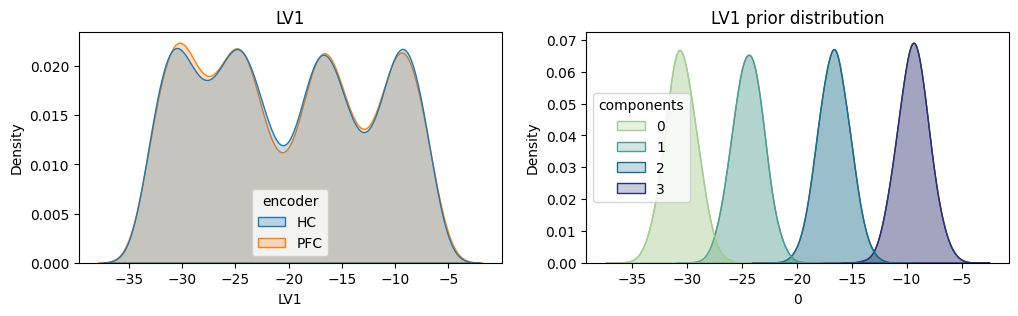

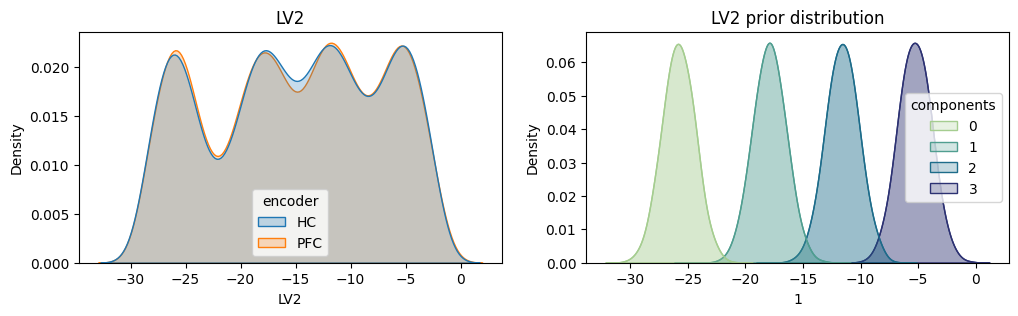

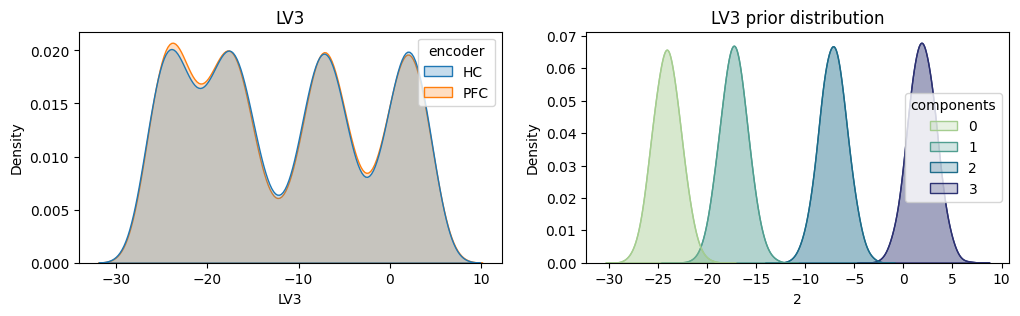

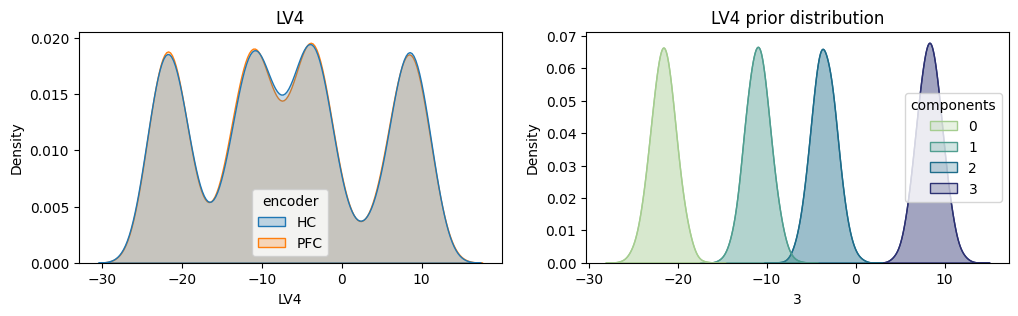

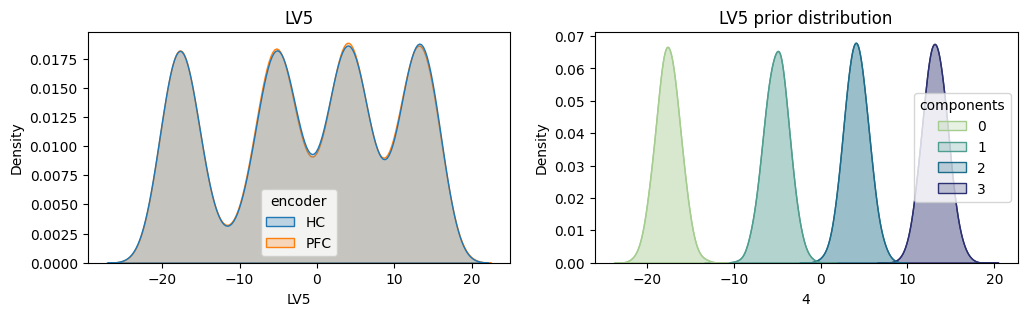

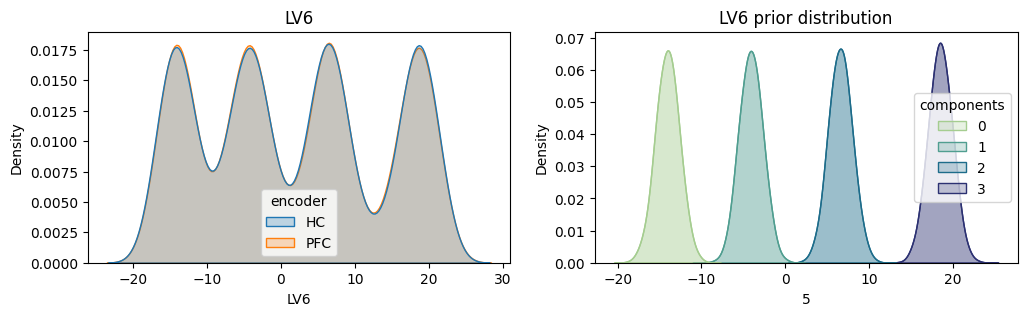

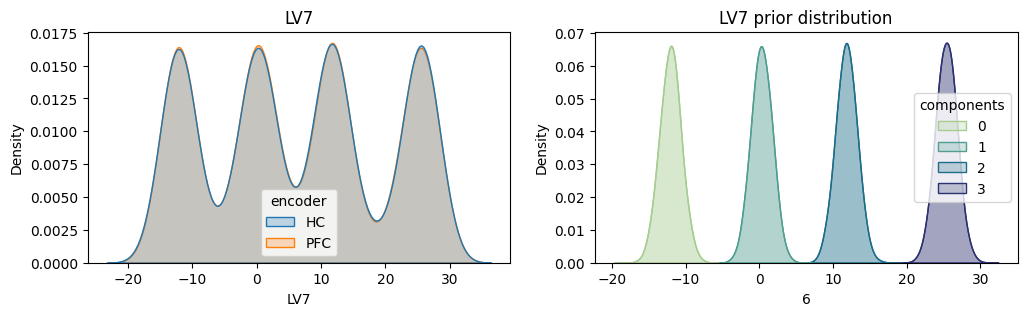

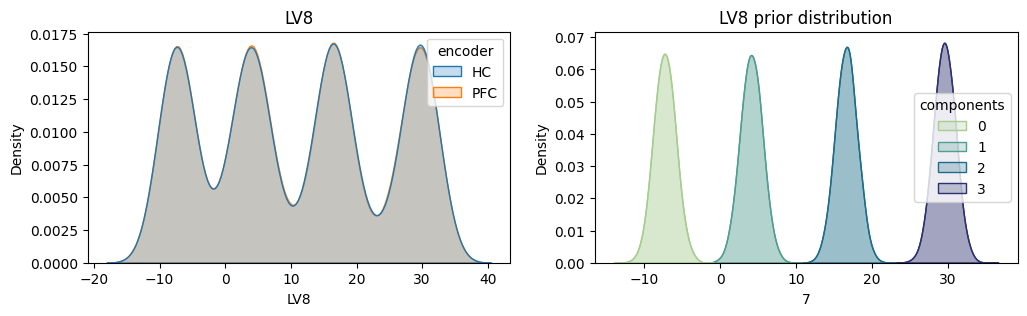

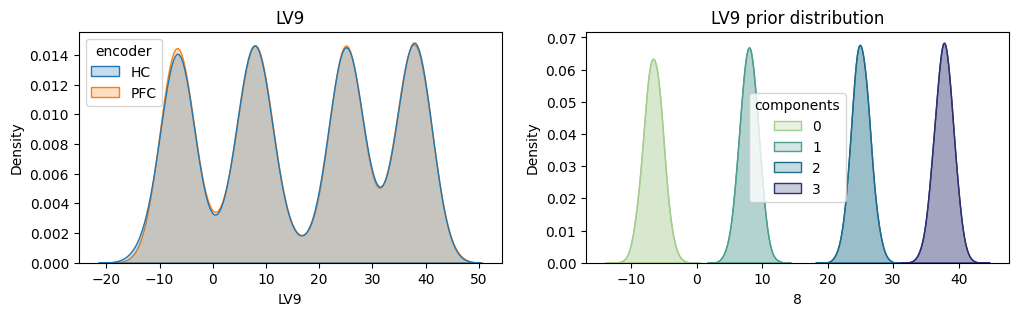

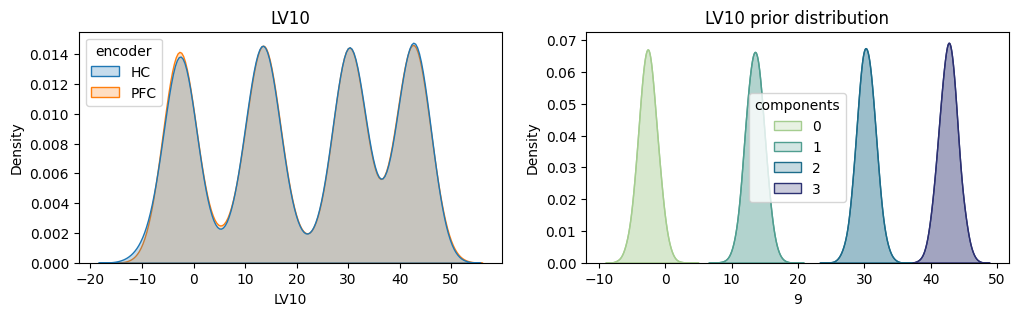

In [5]:
# plot the encoder distributions and corresponding priors
for i, column in enumerate(latent_space_comb.columns[:latent_dim]):
    fig, ax = plt.subplots(1, 2, figsize=(12, 3))
    sns.kdeplot(data=latent_space_comb[[column, 'encoder']], x=column, hue='encoder', fill=True, bw_adjust=1, ax=ax[0])
    ax[0].set_title(column)
    prior_col1 = all_samples[0].columns[i]
    sns.kdeplot(data=all_samples[0][[prior_col1, 'components']], x=prior_col1, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[1])
    current_colors = sns.color_palette().as_hex()
    prior_col2 = all_samples[1].columns[i]
    sns.kdeplot(data=all_samples[1][[prior_col2, 'components']], x=prior_col2, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[1])
    ax[1].set_title(f'{column} prior distribution')

/tmp/ipykernel_435862/27783633.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap1 = cm.get_cmap('gist_heat')
/tmp/ipykernel_435862/27783633.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = cm.get_cmap('Blues')


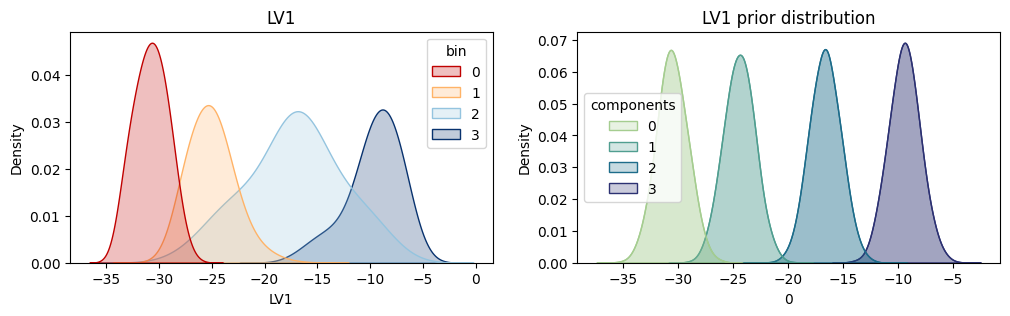

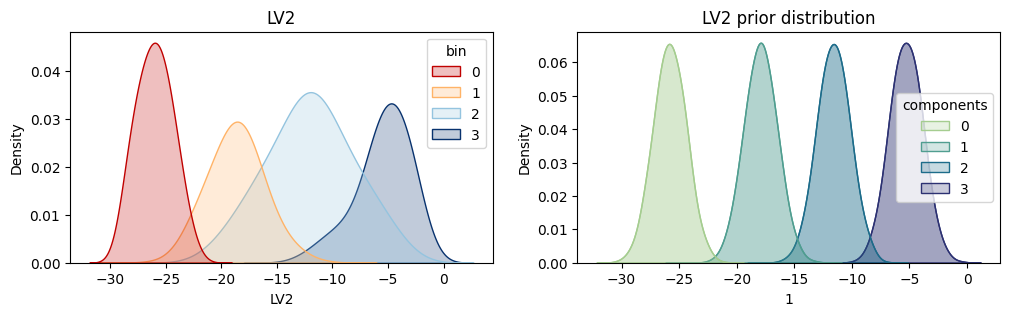

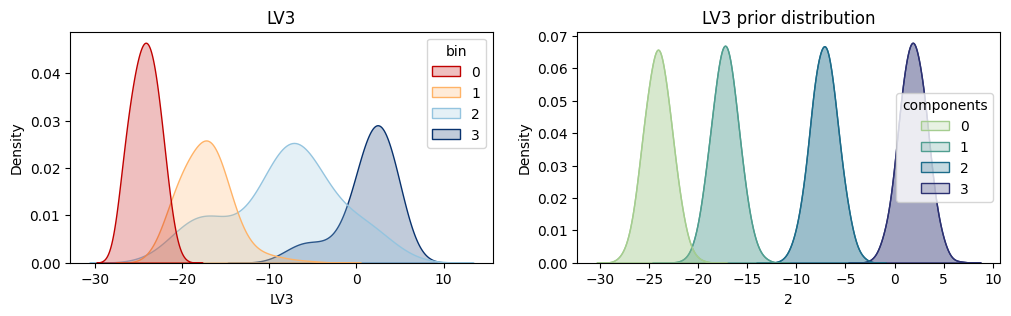

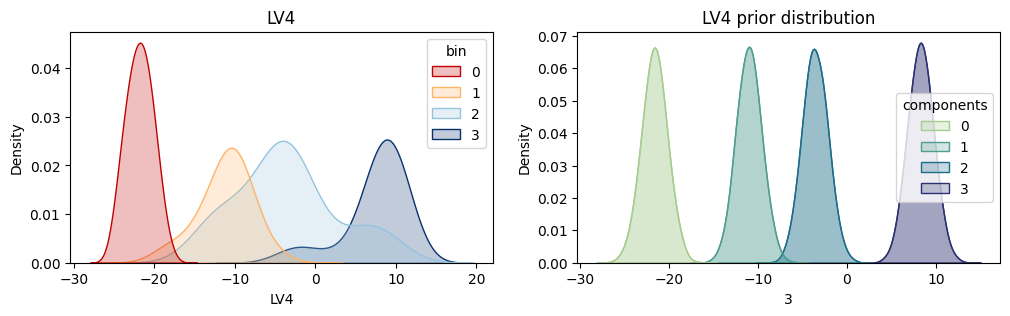

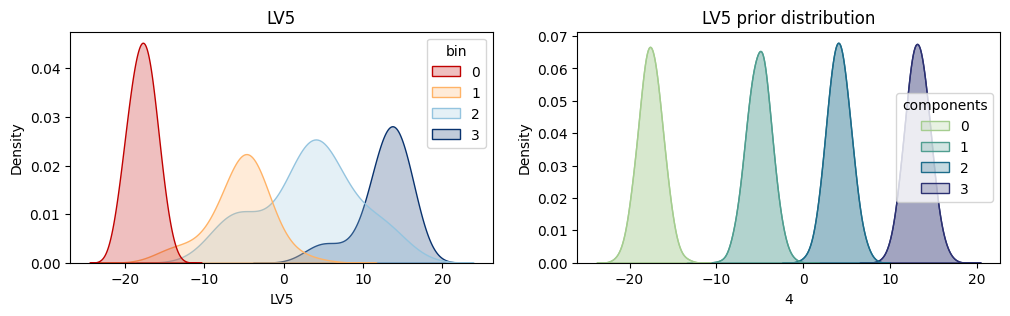

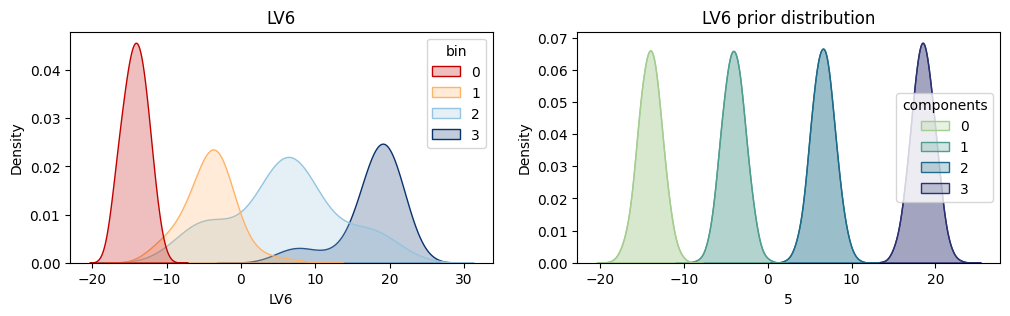

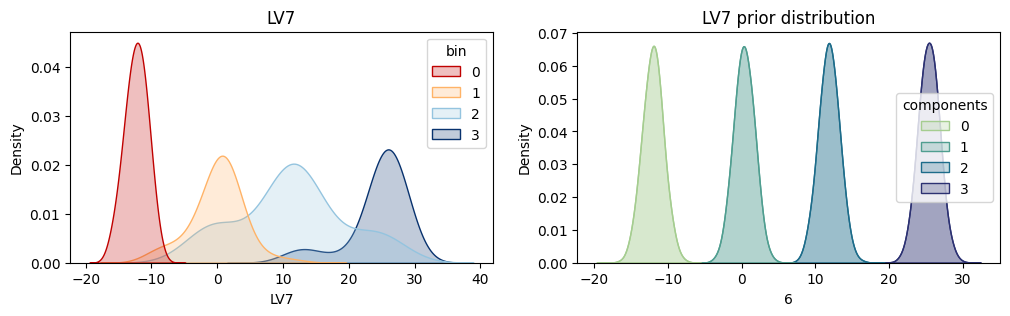

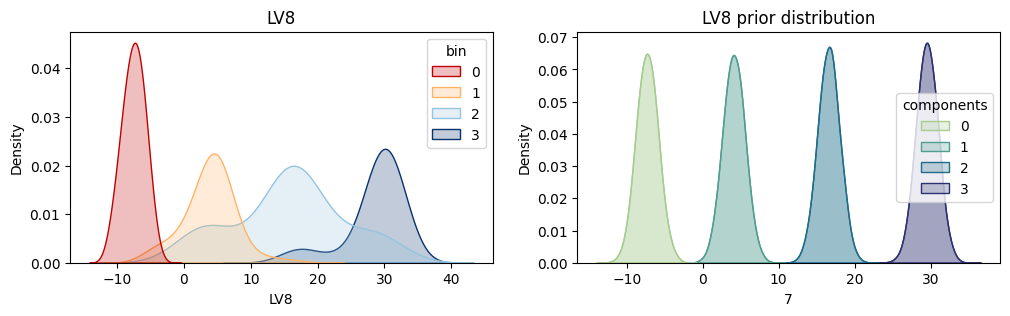

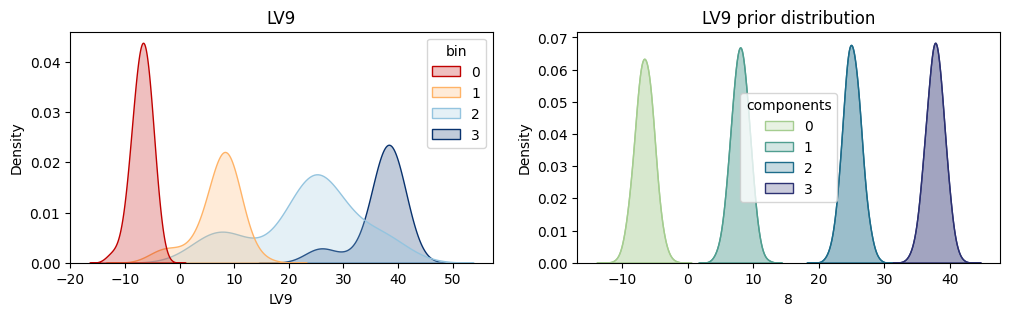

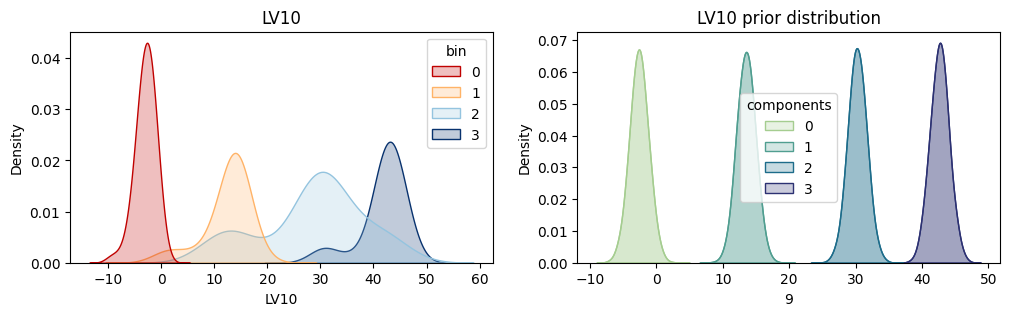

In [6]:
# plot the latent space kde of each resilience bin and corresponding priors
cmap1 = cm.get_cmap('gist_heat')
cmap2 = cm.get_cmap('Blues')
custom_palette = {0: cmap1(0.5), 1: cmap1(0.85), 2: cmap2(0.4), 3: cmap2(0.99)}

for i, column in enumerate(latent_space_comb.columns[:latent_dim]):

    fig, ax = plt.subplots(1, 2, figsize=(12, 3))
    sns.kdeplot(data=latent_space_comb[[column, 'bin']], x=column, hue='bin', palette=custom_palette, fill=True, bw_adjust=3, ax=ax[0])
    ax[0].set_title(column)
    prior_col1 = all_samples[0].columns[i]
    sns.kdeplot(data=all_samples[0][[prior_col1, 'components']], x=prior_col1, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[1])
    prior_col2 = all_samples[1].columns[i]
    sns.kdeplot(data=all_samples[1][[prior_col2, 'components']], x=prior_col2, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[1])
    ax[1].set_title(f'{column} prior distribution')

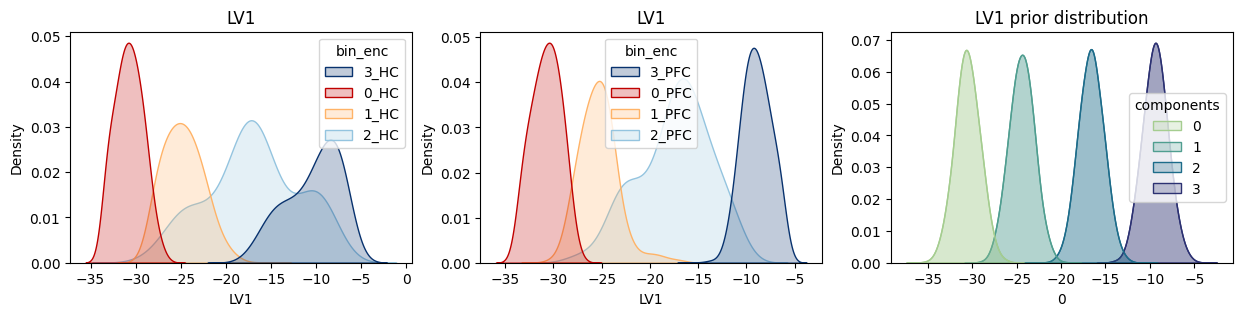

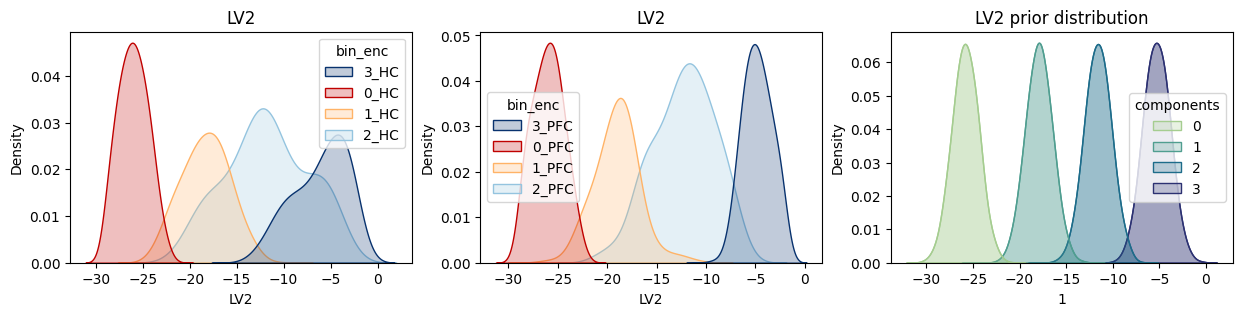

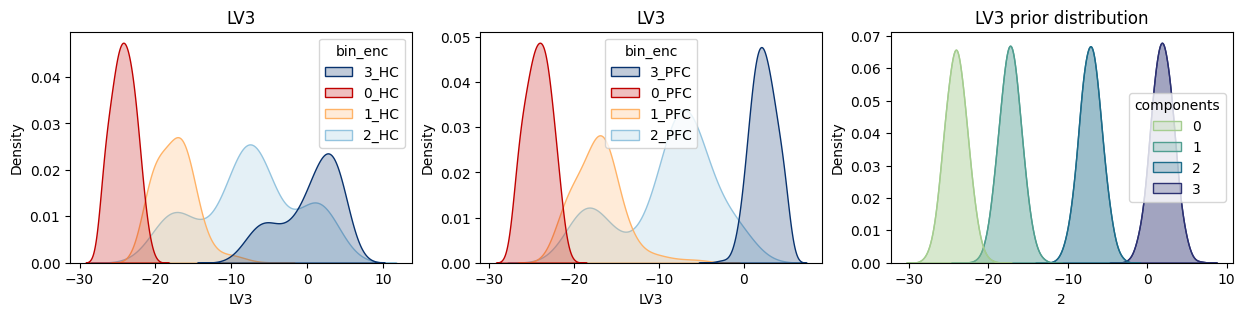

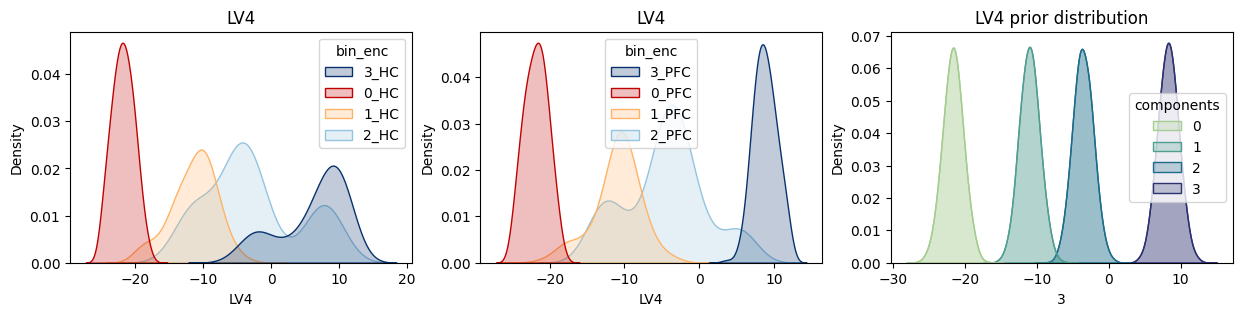

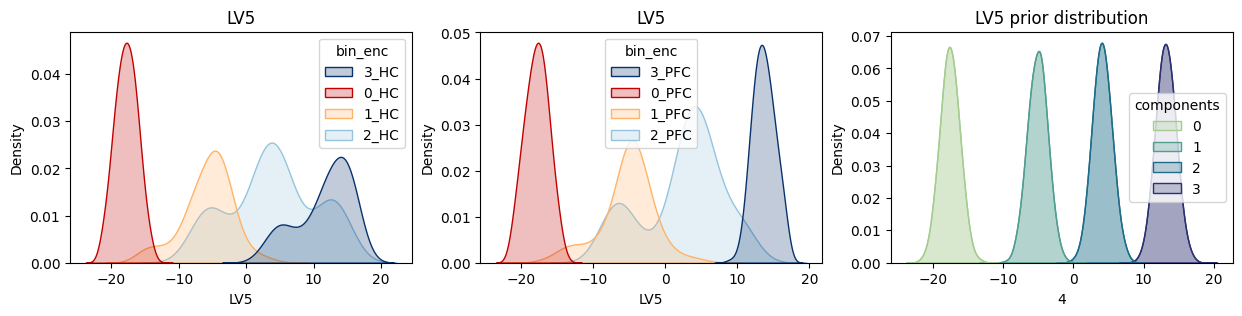

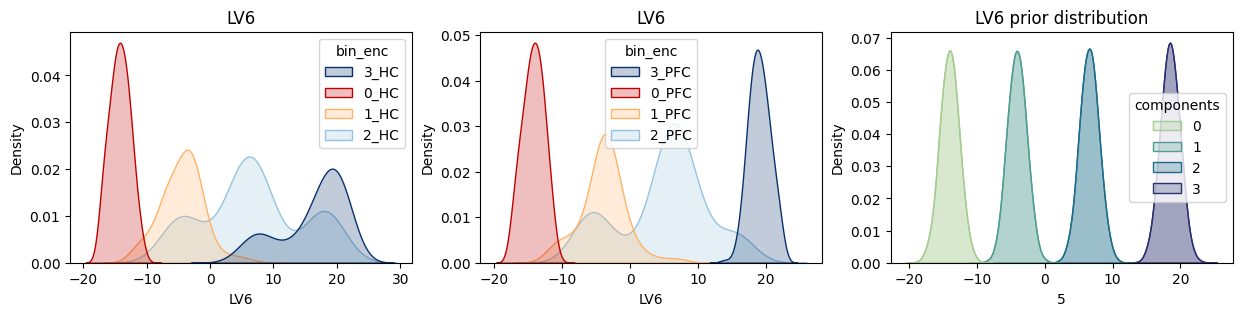

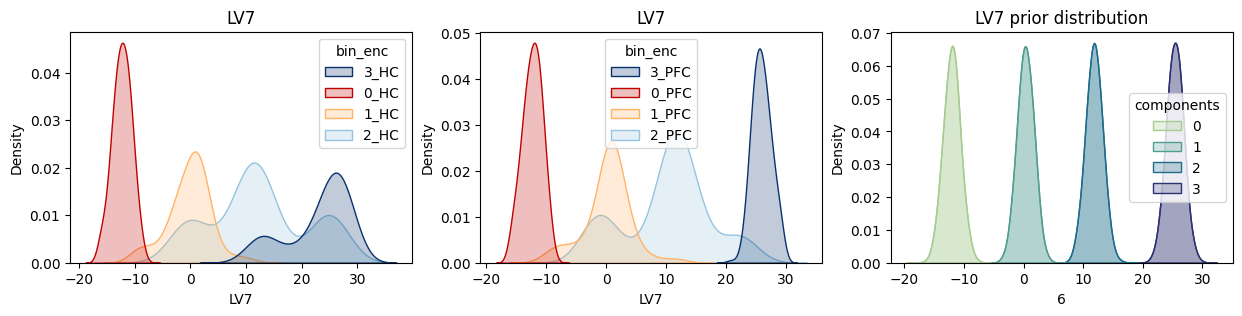

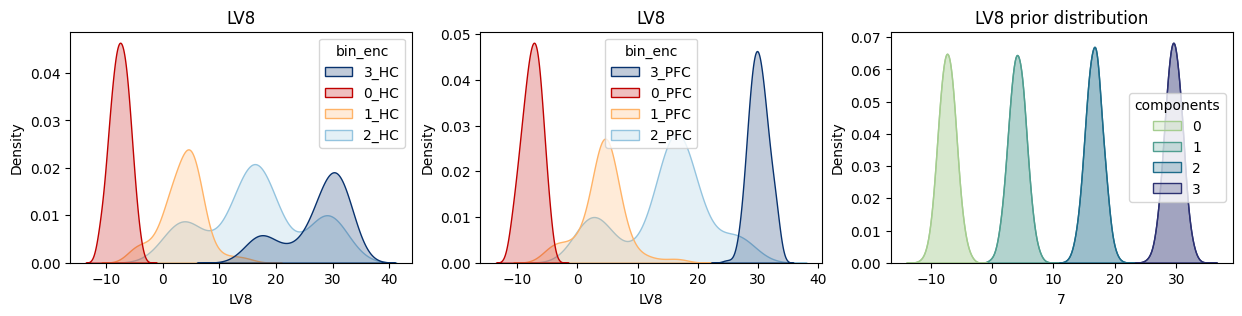

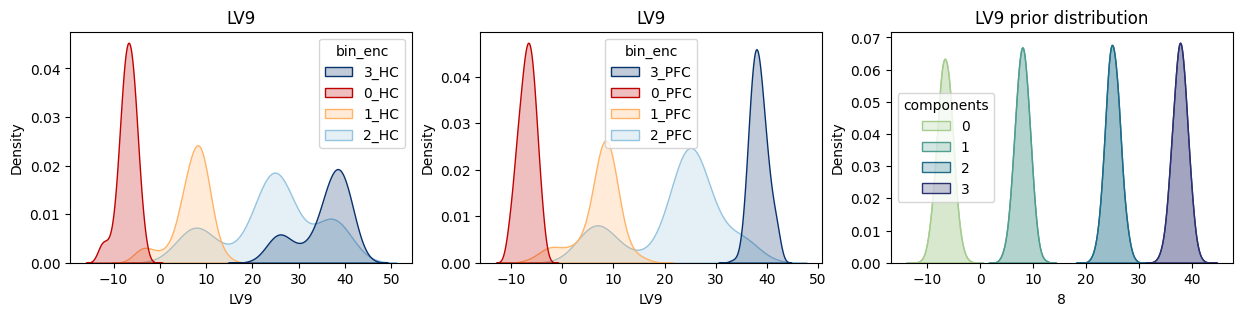

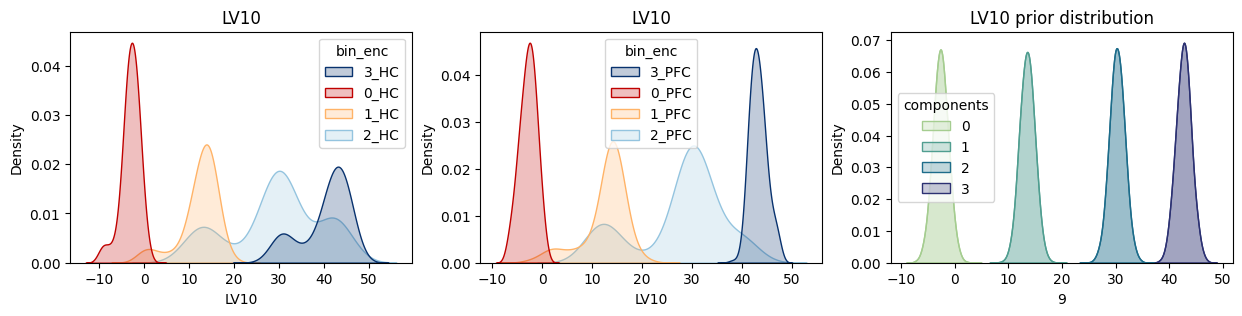

In [7]:
# plot individual latent spaces for each encoder colored by resilience bin and corresponsing priors 
latent_space_comb['bin_enc'] = latent_space_comb['bin'].astype(str) + '_' +  latent_space_comb['encoder']
for i, column in enumerate(latent_space_comb.columns[:latent_dim]):
    fig, ax = plt.subplots(1, 3, figsize=(15, 3))
    palette_HC = {'0_HC': cmap1(0.5), '1_HC': cmap1(0.85), '2_HC': cmap2(0.4), '3_HC': cmap2(0.99)}
    hc = latent_space_comb[latent_space_comb['bin_enc'].str.contains(dataset_abbrev[0])]
    sns.kdeplot(data=hc[[column, 'bin_enc']], x=column, hue='bin_enc', palette=palette_HC, fill=True, bw_adjust=2, ax=ax[0])
    ax[0].set_title(column)
    palette_PFC = {'0_PFC': cmap1(0.5), '1_PFC': cmap1(0.85), '2_PFC': cmap2(0.4), '3_PFC': cmap2(0.99)}
    pfc = latent_space_comb[latent_space_comb['bin_enc'].str.contains(dataset_abbrev[1])]
    sns.kdeplot(data=pfc[[column, 'bin_enc']], x=column, hue='bin_enc', palette=palette_PFC, fill=True, bw_adjust=2, ax=ax[1])
    ax[1].set_title(column)
    prior_col1 = all_samples[0].columns[i]
    sns.kdeplot(data=all_samples[0][[prior_col1, 'components']], x=prior_col1, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[2])
    prior_col2 = all_samples[1].columns[i]
    sns.kdeplot(data=all_samples[1][[prior_col2, 'components']], x=prior_col2, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[2])
    ax[2].set_title(f'{column} prior distribution')

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


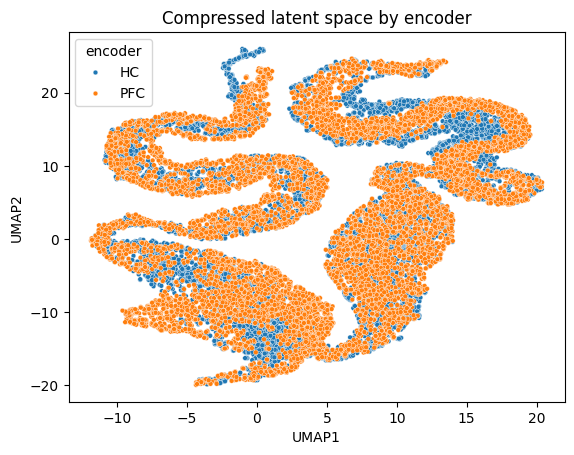

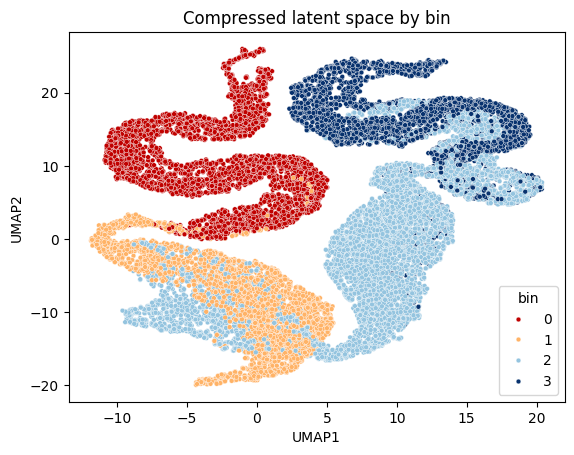

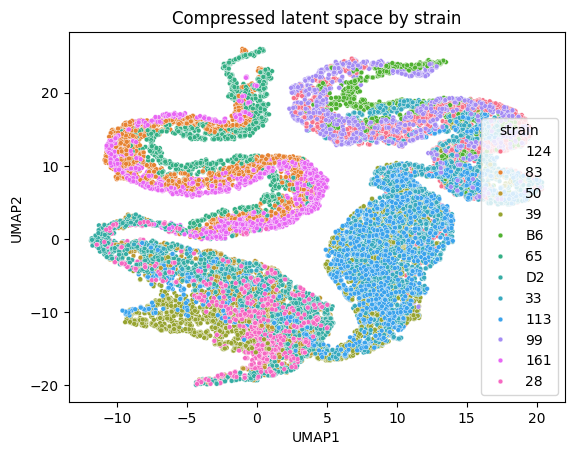

In [8]:
# make umap object 
reducer = umap.UMAP(n_neighbors=50, min_dist=1, n_components=2, random_state=random_seed)
embedding = reducer.fit_transform(latent_space_comb.iloc[:, :latent_dim])
# initialize different hues to color the latent space by 
hues = ['encoder', 'bin', 'strain']
# generate embedding dataframe from compressed representation
embedding_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
embedding_df.to_csv(os.path.join(results_folder, 'latent_umap_embeddings.csv')) # save embedding 
for hue in hues: 
    embedding_df[hue] = latent_space_comb[hue]
# plot umap colored by each of the hues
for hue in hues: 
    plt.figure()
    if hue == 'bin':
        sns.scatterplot(x='UMAP1', y='UMAP2', hue=hue, palette=custom_palette, data=embedding_df, s=12)
    else: 
        sns.scatterplot(x='UMAP1', y='UMAP2', hue=hue, data=embedding_df, s=12)
    plt.title(f'Compressed latent space by {hue}')

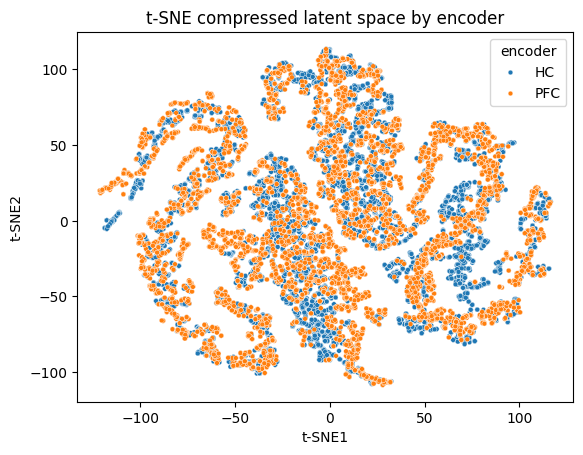

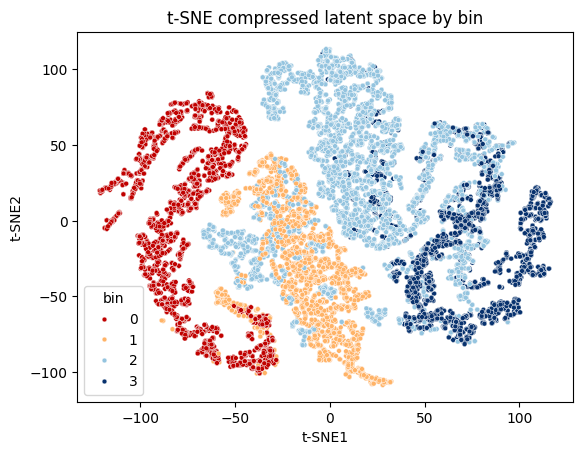

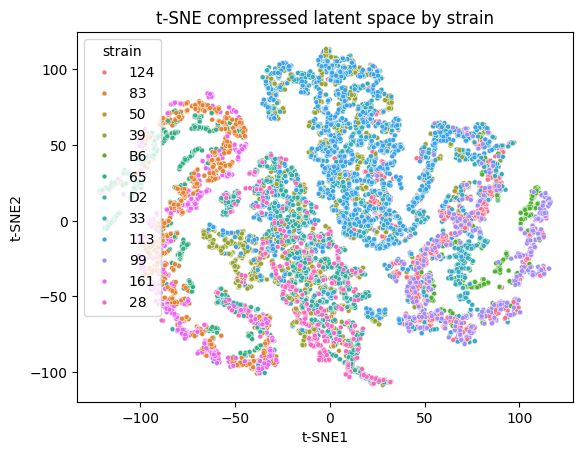

In [9]:
# do the same with tsne dim reduction
tsne = TSNE(n_components=2, perplexity=30, random_state=random_seed)
tsne_embeddings = tsne.fit_transform(latent_space_comb.iloc[:, :latent_dim])
tsne_embedding_df = pd.DataFrame(tsne_embeddings, columns=['t-SNE1', 't-SNE2'])
for hue in hues: 
    tsne_embedding_df[hue] = latent_space_comb[hue]
    plt.figure()
    if hue == 'bin':
        sns.scatterplot(x='t-SNE1', y='t-SNE2', hue=hue, palette=custom_palette, data=tsne_embedding_df, s=12)
    else:
        sns.scatterplot(x='t-SNE1', y='t-SNE2', hue=hue, data=tsne_embedding_df, s=12)
    plt.title(f't-SNE compressed latent space by {hue}')

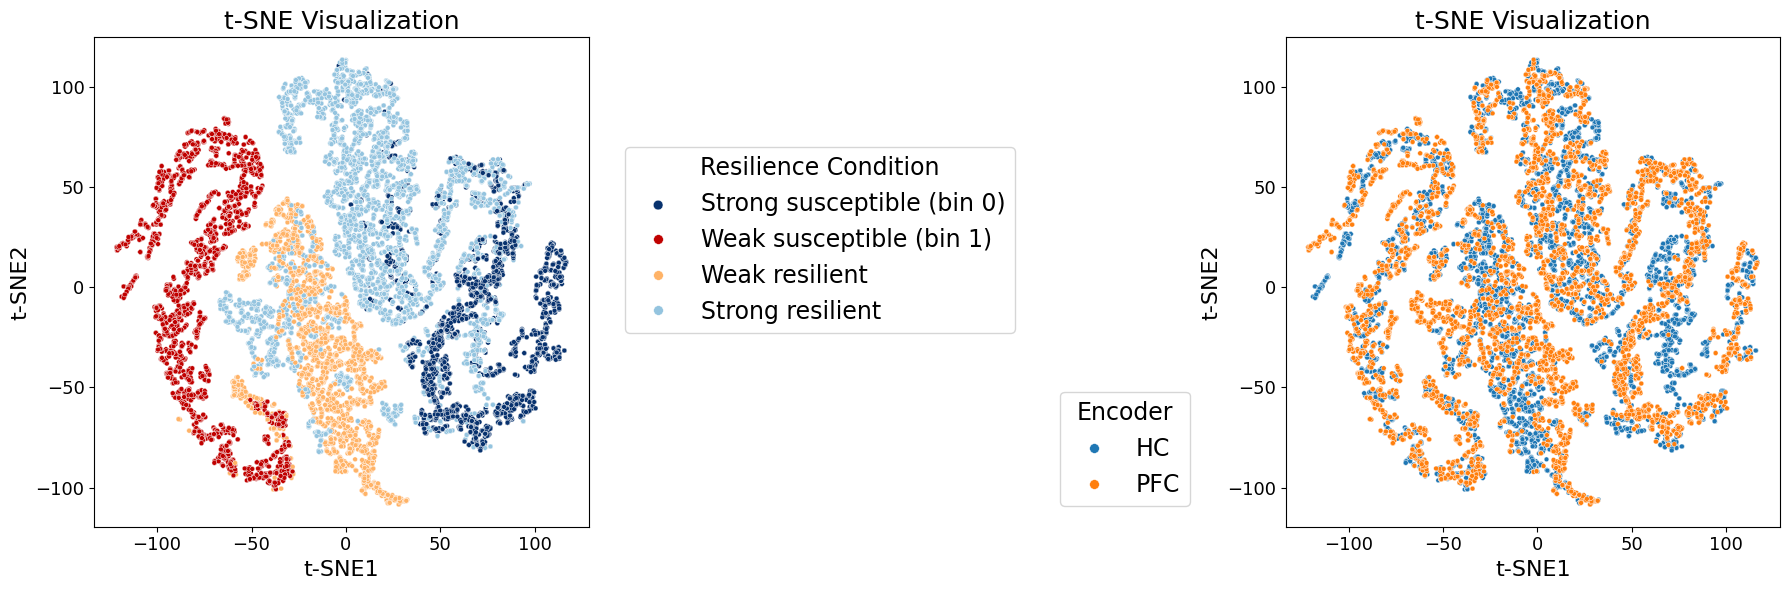

In [10]:
# make nicer tsne visualization and save it to the results folder 
fig, ax = plt.subplots(1, 2, figsize=(18, 6))
legend_labels = ['Strong susceptible (bin 0)', 'Weak susceptible (bin 1)', 'Weak resilient', 'Strong resilient']
sns.scatterplot(x='t-SNE1', y='t-SNE2', hue='bin', palette=custom_palette, data=tsne_embedding_df, s=12, ax=ax[0])
ax[0].set_xlabel('t-SNE1', fontsize=16)
ax[0].set_ylabel('t-SNE2', fontsize=16)
ax[0].legend(title="Resilience Condition",labels=legend_labels,bbox_to_anchor=(1.05, 0.8), markerscale=2.0, fontsize=17, title_fontsize=17)
ax[0].set_title('t-SNE Visualization', fontsize=18)
ax[0].tick_params(axis='both', which='major', labelsize=13)
sns.scatterplot(x='t-SNE1', y='t-SNE2', hue='encoder',  data=tsne_embedding_df, s=12, ax=ax[1])
ax[1].set_xlabel('t-SNE1', fontsize=16)
ax[1].set_ylabel('t-SNE2', fontsize=16)
ax[1].legend(title="Encoder",bbox_to_anchor=(-0.17, 0.3), markerscale=2.0, fontsize=17, title_fontsize=17)
ax[1].set_title('t-SNE Visualization', fontsize=18)
ax[1].tick_params(axis='both', which='major', labelsize=13)
plt.tight_layout()
plt.savefig(os.path.join(results_folder, 'tSNE_colored.png'), dpi=600)

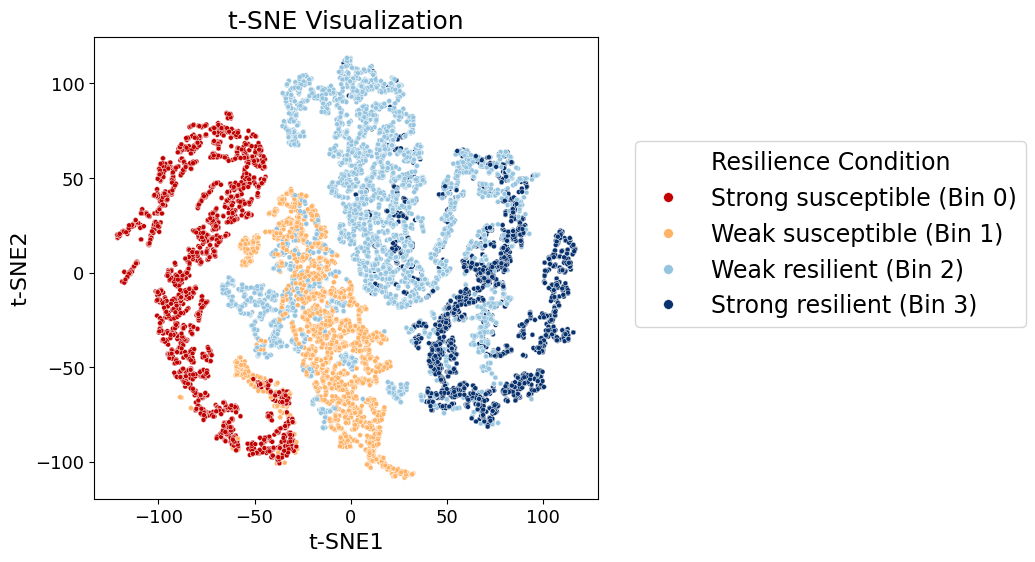

In [11]:
# plot and save t-SNE colored by resilience bin
new_custom_palette  = {'Strong susceptible (Bin 0)': cmap1(0.5), 'Weak susceptible (Bin 1)': cmap1(0.85), 'Weak resilient (Bin 2)': cmap2(0.4), 'Strong resilient (Bin 3)': cmap2(0.99)}
plt.figure(figsize=(6.5, 6))
legend_labels = {0: 'Strong susceptible (Bin 0)', 1: 'Weak susceptible (Bin 1)', 2: 'Weak resilient (Bin 2)', 3:'Strong resilient (Bin 3)'}
tsne_embedding_df['bin_name'] = tsne_embedding_df['bin'].map(legend_labels)
hue_order = ['Strong susceptible (Bin 0)', 'Weak susceptible (Bin 1)', 'Weak resilient (Bin 2)', 'Strong resilient (Bin 3)']
sns.scatterplot(x='t-SNE1', y='t-SNE2', hue='bin_name', hue_order=hue_order, palette=new_custom_palette, data=tsne_embedding_df, s=12)
plt.xlabel('t-SNE1', fontsize=16)
plt.ylabel('t-SNE2', fontsize=16)
plt.legend(title="Resilience Condition",bbox_to_anchor=(1.05, 0.8), markerscale=2.0, fontsize=17, title_fontsize=17)
plt.title('t-SNE Visualization', fontsize=18)
plt.tick_params(labelsize=13)
plt.savefig(os.path.join(results_folder, 'tSNE_bin_colored.png'), dpi=600, bbox_inches='tight')

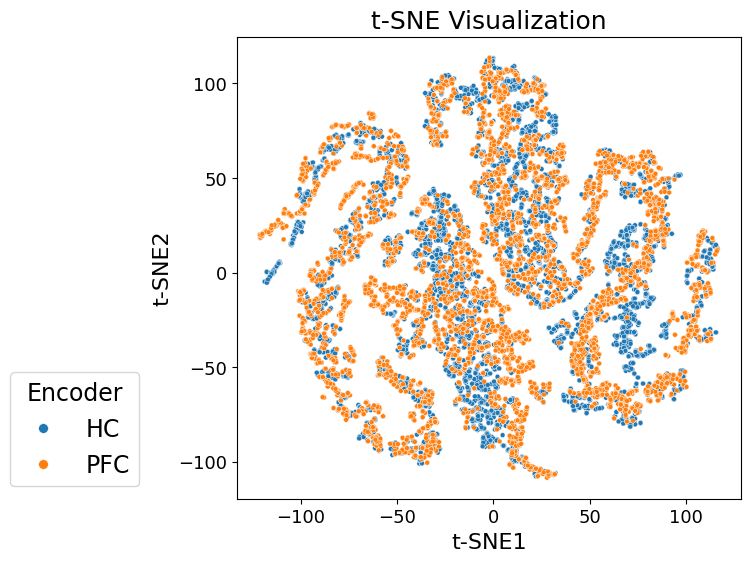

In [12]:
# plot and save t-SNE compressed representation colored by encoders
plt.figure(figsize=(6.5, 6))
encoder_palette = {'HC': '#1f77b4', 'PFC': '#ff7f0e'}
sns.scatterplot(x='t-SNE1', y='t-SNE2', hue='encoder', palette=encoder_palette, data=tsne_embedding_df, s=12)
plt.xlabel('t-SNE1', fontsize=16)
plt.ylabel('t-SNE2', fontsize=16)
plt.legend(title="Encoder",bbox_to_anchor=(-0.17, 0.3), markerscale=2.0, fontsize=17, title_fontsize=17)
plt.title('t-SNE Visualization', fontsize=18)
plt.tick_params(labelsize=13)
plt.savefig(os.path.join(results_folder, 'tSNE_enc_colored.png'), dpi=600, bbox_inches='tight')

Calculate and plot the phenotypic projection

In [13]:
# calculate osd value 
# calculate phenotypic projection
df = latent_space_comb
coord_cols = df.columns[:10]
df[coord_cols] = df[coord_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# find most susceptible/resilience strains
strain_order = (df.sort_values('14-6-residual', ascending=True)['strain'].unique())
strain_sus = strain_order[0]
strain_res = strain_order[-1]

sus = (df[df['strain'] == strain_sus][coord_cols].apply(np.mean, axis=0).values)
res = (df[df['strain'] == strain_res][coord_cols].apply(np.mean, axis=0).values)

proj = df.apply(lambda x: project_row(x, coord_cols, sus, res), axis=1)
df = pd.concat([
    df.reset_index(drop=True),
    pd.DataFrame(proj['Projected'].tolist(), columns=[f'Proj_{i+1}' for i in range(10)]),
    proj[['Signed_Distance']]], axis=1)

sus_cen = (df[df['bin'] == 0][coord_cols].apply(np.mean, axis=0).values)
res_cen = (df[df['bin'] == 3][coord_cols].apply(np.mean, axis=0).values)

_, s_sus_cen = line_coordinates_euclidean(sus, res, sus_cen)
_, s_res_cen = line_coordinates_euclidean(sus, res, res_cen)
#print("Signed distance (sus_cen, res_cen):", s_sus_cen, s_res_cen)

_, sus_strain = line_coordinates_euclidean(sus, res, sus)
_, res_strain = line_coordinates_euclidean(sus, res, res)
#print("Signed distance (sus_strain, res_strain):", sus_strain, res_strain)

# Rename last column as PP (Phenotypic Projection)
df.rename(columns={df.columns[-1]: 'PP'}, inplace=True)

osd = compute_osd(df)

/tmp/ipykernel_435862/929162318.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap1 = cm.get_cmap('gist_heat')
/tmp/ipykernel_435862/929162318.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = cm.get_cmap('Blues')


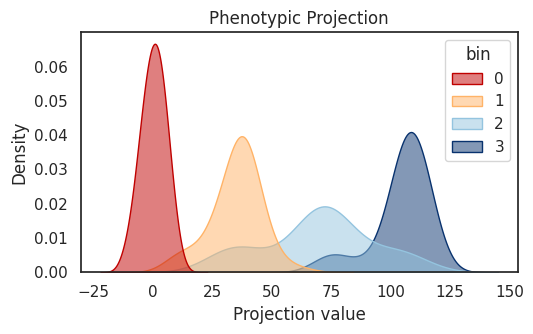

In [14]:
# plot phenotypic projection
sns.set(style="white")
cmap1 = cm.get_cmap('gist_heat')
cmap2 = cm.get_cmap('Blues')
custom_palette = {0: cmap1(0.5), 1: cmap1(0.85), 2: cmap2(0.4), 3: cmap2(0.99)}
bin_order = ['0', '1', '2', '3']
legend_labels = ['Strong susceptible', 'Weak susceptible', 'Weak resilient', 'Strong resilient']
temp = df
plt.figure(figsize=(5.5, 3.5))
ax = sns.kdeplot(data=temp, x='PP',hue="bin",palette=custom_palette,fill=True,alpha=0.5,
                 bw_adjust=3, common_norm=False)
#if not ax.legend:
#plt.legend(title="Resilience Consdition",labels=legend_labels,bbox_to_anchor=(1.05, 1))
plt.title("")
plt.xlabel('Projection value')
#plt.title(f'OSD: {osd['osd']}')
plt.title('Phenotypic Projection')
plt.savefig(os.path.join(results_folder, 'phenotypic_projection.png'), dpi=500, bbox_inches='tight')
plt.tight_layout()
plt.show()

Latent space f-statistics

In [15]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import f_classif

le = LabelEncoder()
y = le.fit_transform(latent_space_comb['encoder'])
# calculate f-statistics between encoders
latent_cols = latent_space_comb.iloc[:, :latent_dim].columns 
f_values, p_values = f_classif(latent_space_comb.iloc[:, :latent_dim], y)
latents_ordered = np.argsort(f_values)[::-1]
fclass_importance_df = pd.DataFrame({
    'Latent variable': latent_cols, 
    'f_values': f_values,
    'p_values': p_values
}).sort_values(by='f_values', ascending=False)
fclass_importance_df

,Latent variable,f_values,p_values
1,LV2,4.824112e-02,0.826155
7,LV8,2.047167e-02,0.886229
2,LV3,1.839285e-02,0.892123
6,LV7,1.775794e-02,0.893990
0,LV1,1.703994e-02,0.896143
5,LV6,1.539801e-02,0.901246
9,LV10,4.782798e-03,0.944865
3,LV4,3.937544e-03,0.949966
8,LV9,1.585839e-05,0.996823
4,LV5,1.129002e-07,0.999732


SVM to predict features relevant to encoder classification

(0.0, 6.0)

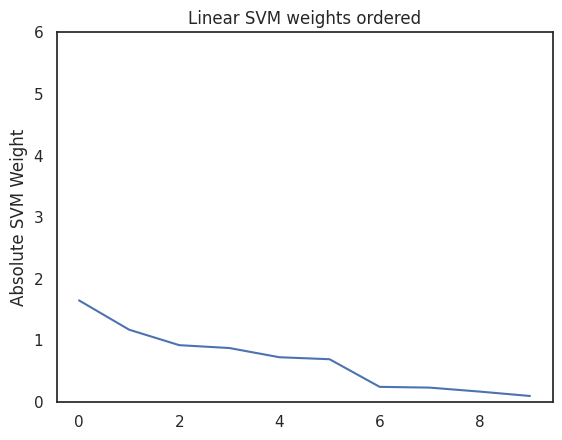

In [16]:
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
# with linear kernel 
linear_model = SVC(kernel='linear')
linear_model.fit(latent_space_comb.iloc[:, :latent_dim], y)
weights = linear_model.coef_[0]
importance_df = pd.DataFrame({
    'Latent variable': latent_cols, 
    'Weight': weights, 
    'Abs_weight': abs(weights)
}).sort_values(by='Abs_weight', ascending=False)
# save linear model weights 
importance_df.to_csv(os.path.join(results_folder, 'linear_svm_weights.csv'))
# also plot learned model weights 
plt.plot(np.arange(latent_dim), importance_df['Abs_weight'])
plt.title('Linear SVM weights ordered')
plt.ylabel('Absolute SVM Weight')
plt.ylim(0, 6)

In [17]:
# rbf_model = SVC(kernel='rbf')
# rbf_model.fit(latent_space_comb.iloc[:, :latent_dim], y)
# results = permutation_importance(rbf_model, latent_space_comb.iloc[:, :latent_dim], y, n_repeats=10, random_state=random_seed)
# rbf_importance_df = pd.DataFrame({
#     'Latent variable': latent_cols, 
#     'Weight': results.importances_mean, 
#     'Abs_weight': abs(results.importances_mean)
# }).sort_values(by='Abs_weight', ascending=False)
# rbf_importance_df.to_csv(os.path.join(results_folder, 'rbf_svm_weights.csv'))
# rbf_importance_df

Generate correlation plots between latent variables 

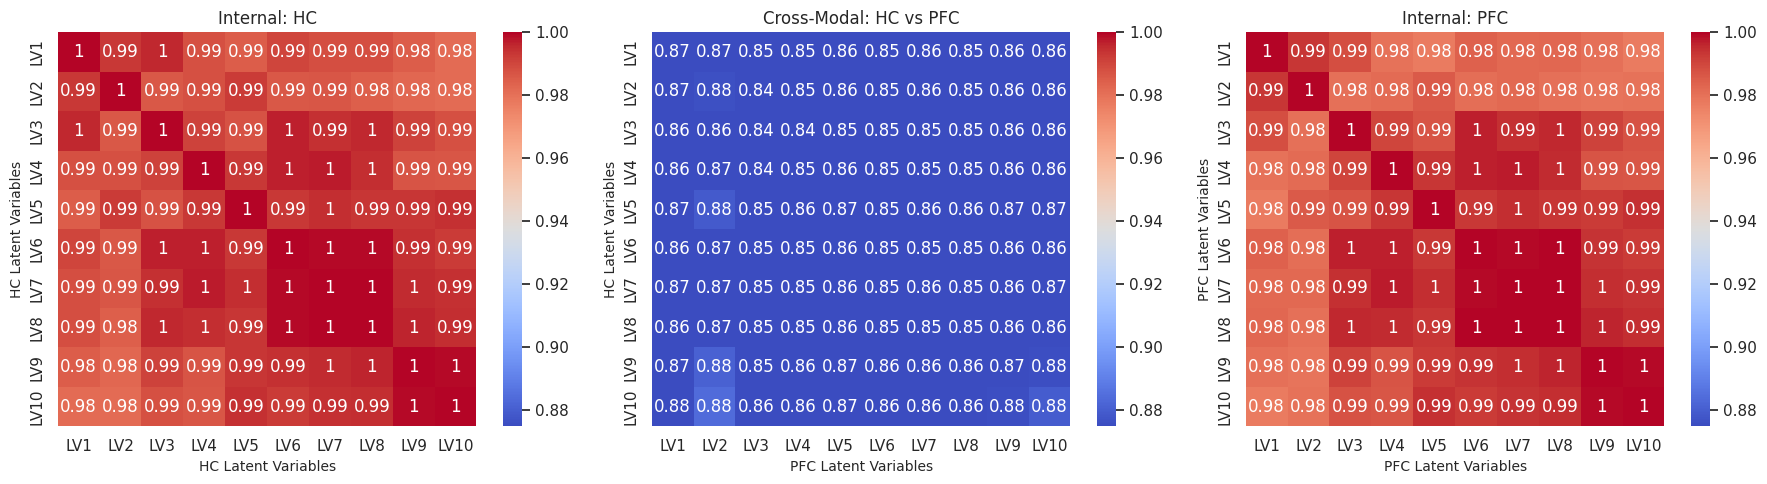

In [18]:
from itertools import combinations_with_replacement
unique_encoders = latent_space_comb['encoder'].unique()
encoder_pairs = list(combinations_with_replacement(unique_encoders, 2))

# Filter pairs first to ensure we only plot valid combinations
valid_pairs = []
for enc1, enc2 in encoder_pairs:
    z1 = latent_space_comb[latent_space_comb['encoder'] == enc1].iloc[:, :latent_dim]
    z2 = latent_space_comb[latent_space_comb['encoder'] == enc2].iloc[:, :latent_dim]
    if len(z1) == len(z2):
        valid_pairs.append((enc1, enc2, z1, z2))
    else:
        print(f"Skipping {enc1} vs {enc2} due to row count mismatch.")

num_plots = len(valid_pairs)

if num_plots > 0:
    # Initialize a single figure with subplots side-by-side
    fig, axes = plt.subplots(1, num_plots, figsize=(6 * num_plots, 5), sharey=False)
    
    # Ensure axes is iterable even if there's only 1 plot
    if num_plots == 1:
        axes = [axes]

    for i, (enc1, enc2, z1, z2) in enumerate(valid_pairs):
        ax = axes[i]
        
        # Calculate cross-correlation
        stacked = np.hstack((z1, z2))
        full_corr = np.corrcoef(stacked.T)
        cross_corr = full_corr[:latent_dim, latent_dim:]

        # Plot heatmap on the specific subplot axis
        # cbar_ax creates a shared or individual colorbar; keeping it standard here
        sns.heatmap(
            cross_corr, 
            annot=True, 
            cmap='coolwarm', 
            xticklabels=latent_cols,
            yticklabels=latent_cols, 
            vmin=0.875, 
            vmax=1,
            ax=ax  # Directs seaborn to the correct subplot
        )
        
        ax.set_xlabel(f"{enc2} Latent Variables", fontsize=10)
        ax.set_ylabel(f"{enc1} Latent Variables", fontsize=10)
        
        if enc1 == enc2:
            ax.set_title(f"Internal: {enc1}", fontsize=12)
        else:
            ax.set_title(f"Cross-Modal: {enc1} vs {enc2}", fontsize=12)

    plt.tight_layout()
    
    # Save the combined figure
    save_path = os.path.join(results_folder, "Combined_Latent_Correlations.png")
    plt.savefig(save_path, dpi=300)
    plt.show()
else:
    print("No valid encoder pairs found to plot.")

Plot distance between paired datapoints

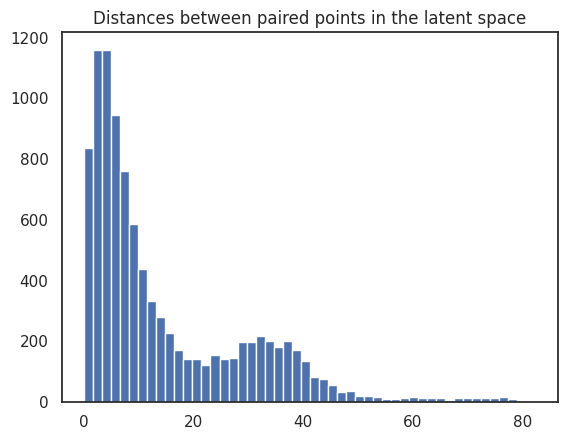

In [19]:
latent_space_comb['pair'] = np.tile(np.arange(1, int(19502 / 2) + 1), 2)
hc = latent_space_comb.iloc[0:9751, :latent_dim]
pfc = latent_space_comb.iloc[9751:, :latent_dim]
paired_distances = np.linalg.norm(hc.values - pfc.values, axis=1)
plt.hist(paired_distances, bins=50)
plt.title('Distances between paired points in the latent space')
plt.savefig(os.path.join(results_folder, 'paired_distances.png'))

Latent traversal

In [20]:
#initialize relevant functions
# function that takes a latent point, finds the count of the k nearest points, and returns the most popular label 
def find_label(all_latent_data, traversal_point, y, k=20):
    device = traversal_point.device
    all_latent_data = all_latent_data.to(device)
    y = y.to(device)
    dist = torch.linalg.norm(all_latent_data - traversal_point.squeeze(0), dim=1)
    _, top_k_indices = torch.topk(dist, k, largest=False)
    label = torch.mode(y[top_k_indices]).values.item()
    return torch.tensor(label, dtype=torch.long)

#v1 latent traversal
def latent_traversal(model, latent_data, device, traversal_dim, latent_dims, model_type, y, num_steps=10, latent_range=5, k=20): 
    model.eval()
    
    mean_latent_data = torch.Tensor(latent_data.iloc[:, :10].mean(axis=0).values.reshape(1, latent_dims))

    with torch.no_grad(): 
        num_samples = mean_latent_data.size(0)

        traversal_values = torch.linspace(-latent_range, latent_range, steps=num_steps)
        traversal_points = mean_latent_data.unsqueeze(0)

        var1_total = 0
        var2_total = 0

        for sample in range(num_samples):
            recon_m1comb = []
            recon_m2comb = []
            for i, z_val in enumerate(traversal_values): 
                z_step = traversal_points[:, sample, :].clone().reshape(1, latent_dims)
                z_step[:, traversal_dim - 1] = z_val
                
                if model_type == 'VAE':
                    recon_m1, _ = model.vaes[0].decode(z_step.float()).to(device)
                    recon_m2, _ = model.vaes[1].decode(z_step.float()).to(device)
                elif model_type == 'CVAE' or model_type == 'CGMVAE':
                    label = find_label(torch.Tensor(latent_space_comb.iloc[:, :10].values), z_step, y, k)
                    recon_m1, _ = model.vaes[0].decode(z_step.float().to(device), label.to(device))
                    recon_m2, _ = model.vaes[1].decode(z_step.float().to(device), label.to(device))

                recon_m1comb.append(recon_m1)
                recon_m2comb.append(recon_m2)
    
            all_recons_m1 = torch.cat(recon_m1comb, dim=0)
            all_recons_m2 = torch.cat(recon_m2comb, dim=0)

            # feature_var1_norm = (torch.var(all_recons_m1, dim=0).cpu().numpy() / m1_var.T).squeeze()
            # feature_var2_norm = (torch.var(all_recons_m2, dim=0).cpu().numpy() / m2_var.T).squeeze()

            # no normalization
            feature_var1_norm = (torch.var(all_recons_m1, dim=0).cpu().numpy()).squeeze()
            feature_var2_norm = (torch.var(all_recons_m2, dim=0).cpu().numpy()).squeeze()

            var1_total += feature_var1_norm.mean().item()
            var2_total += feature_var2_norm.mean().item()
    return var1_total / num_samples, var2_total / num_samples

def latent_traversal_with_corr_midpoint(model, latent_data, device, traversal_dim, latent_dims, model_type, y, num_steps=10, k=20):
    model.train()
    
    # load in mean and std for generating decoded cfm
    stats_cfm = pd.read_csv('/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/stats_cfm.csv')
    cfm_mean, cfm_std = stats_cfm['mean'].item(), stats_cfm['std'].item()

    # Use your established logic for mean latent data
    mid_latent_data = torch.Tensor((latent_data.iloc[:, :latent_dims].min(axis=0) + latent_data.iloc[:, :latent_dims].max(axis=0)) / 2)
    
    traversal_values = torch.linspace(np.min(latent_space_comb.iloc[:, traversal_dim-1]), np.max(latent_space_comb.iloc[:, traversal_dim-1]), steps=num_steps)
    
    var1_total, var2_total = 0, 0
    corr1_total, corr2_total = 0, 0
    
    with torch.no_grad():
        z_batch = mid_latent_data.repeat(num_steps, 1).to(device)
        t_values = torch.as_tensor(traversal_values, device=device, dtype=torch.float32)
        z_batch[:, traversal_dim - 1] = t_values

        if model_type == 'VAE':
            recon_m1, _ = model.vaes[0].decode(z_batch)
            recon_m2, _ = model.vaes[1].decode(z_batch)
        else:
            labels = torch.stack([find_label(torch.Tensor(latent_space_comb.iloc[:, :latent_dims].values), 
                                    z.unsqueeze(0), y, k) for z in z_batch]).to(device)
        
            recon_m1, _ = model.vaes[0].decode(z_batch, labels)
            recon_m2, _ = model.vaes[1].decode(z_batch, labels)
    
        recon_m1_final = recon_m1[:, :-1].detach()
        recon_m2_final = recon_m2[:, :-1].detach()

        cfm1_batch = (recon_m1[:, -1] * cfm_std) + cfm_mean
        cfm2_batch = (recon_m2[:, -1] * cfm_std) + cfm_mean
        
        # 1. Variance Calculation (Existing)
        var1_total += torch.var(recon_m1_final, dim=0).mean().item()
        var2_total += torch.var(recon_m2_final, dim=0).mean().item()
         
        # Correlate across the traversal steps
        c1, _ = pearsonr(traversal_values.cpu().numpy(), cfm1_batch.detach().cpu().numpy())
        c2, _ = pearsonr(traversal_values.cpu().numpy(), cfm2_batch.detach().cpu().numpy())
    
        corr1_total += np.nan_to_num(c1)
        corr2_total += np.nan_to_num(c2)
            
    return (var1_total, var2_total), (c1, c2), traversal_values, [recon_m1_final.cpu().numpy(), recon_m2_final.cpu().numpy()]

In [21]:
# initialize device 
# set device to gpu if available 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# initialize variance from standardization to unstandardize
m1_var_path = '/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/HC30perc_var.csv' # '/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/genoprobs_var.csv' 
m2_var_path = '/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/PFC30perc_var.csv' # '/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/physio_var.csv' 
m1_var = pd.read_csv(m1_var_path)
m2_var = pd.read_csv(m2_var_path)
vae = torch.load(os.path.join(results_folder, f'saved_model_epoch{epoch}.pth'), map_location=device, weights_only=False)

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/torch/cuda/__init__.py:182: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [22]:
# outcome of traversal with v1 function
std = latent_space_comb.iloc[:, :10].std(axis=0)
all_dims = list(range(1, latent_dim+1))
y = torch.Tensor(latent_space_comb['bin'].values).int()
for dim in all_dims: 
    print(f'Dimension of interest: {dim}')
    latent_range = 3 * std.iloc[dim-1]
    var1, var2 = latent_traversal(vae, latent_space_comb, device, dim, latent_dim, model_type, y=y, num_steps=10, latent_range=latent_range, k=20)
    print(f'{dataset_abbrev[0]} variance: {var1}, {dataset_abbrev[1]} variance: {var2}')
    if var2 != 0.0:
        print(f'Variance ratio ({dataset_abbrev[0]}/{dataset_abbrev[1]}): {var1/var2}')
    else:
        print('Variance is 0.0')
        # print(f'Variance ratio ({dataset_abbrev[0]}/{dataset_abbrev[1]}): {var1/1e-15}')

Dimension of interest: 1
HC variance: 390.968994140625, PFC variance: 1101.35107421875
Variance ratio (HC/PFC): 0.35499034167462107
Dimension of interest: 2
HC variance: 411.5761413574219, PFC variance: 7.2859978675842285
Variance ratio (HC/PFC): 56.48864422381248
Dimension of interest: 3
HC variance: 511.91070556640625, PFC variance: 218.85467529296875
Variance ratio (HC/PFC): 2.339043956365746
Dimension of interest: 4
HC variance: 147.7707061767578, PFC variance: 1327.9302978515625
Variance ratio (HC/PFC): 0.11127896277073707
Dimension of interest: 5
HC variance: 419.03509521484375, PFC variance: 1013.6514892578125
Variance ratio (HC/PFC): 0.41339168309381946
Dimension of interest: 6
HC variance: 232.90139770507812, PFC variance: 805.2537841796875
Variance ratio (HC/PFC): 0.2892273247027767
Dimension of interest: 7
HC variance: 193.81948852539062, PFC variance: 1032.4447021484375
Variance ratio (HC/PFC): 0.18772868718495747
Dimension of interest: 8
HC variance: 90.99027252197266, PFC

In [23]:
from scipy.stats import pearsonr

def latent_traversal_with_corr(model, latent_data, device, traversal_dim, latent_dims, model_type, y, num_steps=10, k=20):
    model.train()
    
    # load in mean and std for generating decoded cfm
    stats_cfm = pd.read_csv('/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/stats_cfm.csv')
    cfm_mean, cfm_std = stats_cfm['mean'].item(), stats_cfm['std'].item()

    # Use your established logic for mean latent data
    mean_latent_data = torch.Tensor(latent_data.iloc[:, :latent_dims].mean(axis=0).values.reshape(1, latent_dims))
    
    traversal_values = torch.linspace(np.min(latent_space_comb.iloc[:, traversal_dim-1]), np.max(latent_space_comb.iloc[:, traversal_dim-1]), steps=num_steps)
    
    all_var_1, all_var_2 = [], []
    var1_total, var2_total = 0, 0
    corr1_total, corr2_total = 0, 0
    
    with torch.no_grad():

        z_batch = mean_latent_data.repeat(num_steps, 1).to(device)
        t_values = torch.as_tensor(traversal_values, device=device, dtype=torch.float32)
        z_batch[:, traversal_dim - 1] = t_values

        if model_type == 'VAE':
            recon_m1, _ = model.vaes[0].decode(z_batch)
            recon_m2, _ = model.vaes[1].decode(z_batch)
        else:
            labels = torch.stack([find_label(torch.Tensor(latent_space_comb.iloc[:, :latent_dims].values), 
                                    z.unsqueeze(0), y, k) for z in z_batch]).to(device)
        
            recon_m1, _ = model.vaes[0].decode(z_batch, labels)
            recon_m2, _ = model.vaes[1].decode(z_batch, labels)
    
        recon_m1_final = recon_m1[:, :-1].detach()
        recon_m2_final = recon_m2[:, :-1].detach()

        cfm1_batch = (recon_m1[:, -1] * cfm_std) + cfm_mean
        cfm2_batch = (recon_m2[:, -1] * cfm_std) + cfm_mean
        
        # 1. Variance Calculation (Existing)
        var1_total += torch.var(recon_m1_final, dim=0).mean().item()
        var2_total += torch.var(recon_m2_final, dim=0).mean().item()

        all_var_1 = torch.var(recon_m1_final, dim=0).detach().cpu().numpy()
        all_var_2 = torch.var(recon_m2_final, dim=0).detach().cpu().numpy()
         
        # Correlate across the traversal steps
        c1, _ = pearsonr(traversal_values.cpu().numpy(), cfm1_batch.detach().cpu().numpy())
        c2, _ = pearsonr(traversal_values.cpu().numpy(), cfm2_batch.detach().cpu().numpy())
    
        corr1_total += np.nan_to_num(c1)
        corr2_total += np.nan_to_num(c2)
            
    return (var1_total, var2_total), (c1, c2), traversal_values, [recon_m1_final.cpu().numpy(), recon_m2_final.cpu().numpy()], (all_var_1, all_var_2), (cfm1_batch.detach().cpu().numpy(), cfm2_batch.detach().cpu().numpy())

In [24]:
def plot_multi_metrics(vars, corrs, dim):
    fig, ax = plt.subplots(2, 2, figsize=(10, 5))

    # Plot Variance
    for i, dataset in enumerate(dataset_abbrev):
        ax[i, 0].plot(list(range(1, 11)), vars[i], color='tab:blue', label='Variance')
        ax[i, 0].set_xlabel('Latent Dim')
        ax[i, 0].set_ylabel('Variance', color='tab:blue')
        
        ax[i, 1].plot(list(range(1, 11)), corrs[i], color='tab:red', linestyle='--', label='Correlation')
        ax[i, 1].set_ylabel('Pearson Correlation', color='tab:red')
        ax[i, 1].set_xlabel('Latent Dim')
        ax[i, 0].set_title(f'{dataset} Traversal')
    
    fig.tight_layout()
    plt.show()

Dimension of interest: 1
Dimension of interest: 2
Dimension of interest: 3
Dimension of interest: 4
Dimension of interest: 5
Dimension of interest: 6
Dimension of interest: 7
Dimension of interest: 8
Dimension of interest: 9
Dimension of interest: 10


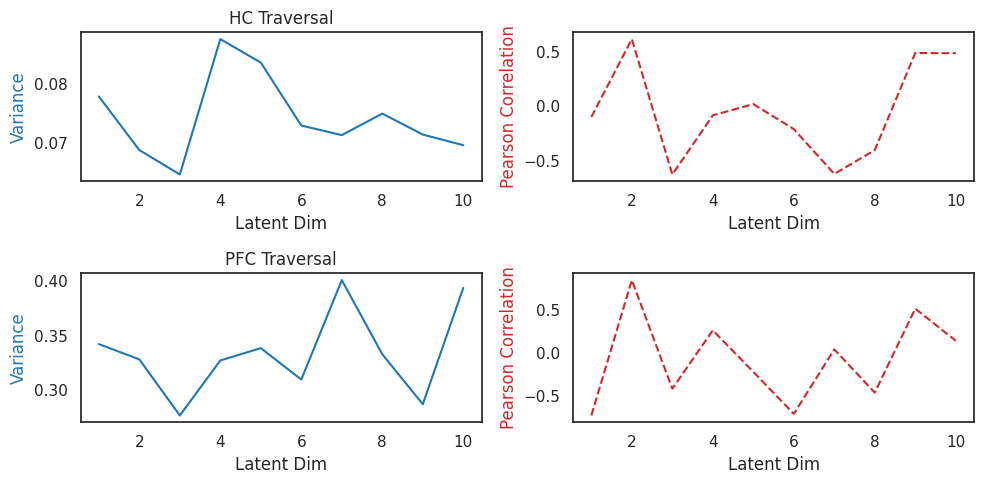

In [25]:
hc_variance = []
pfc_variance = []
hc_corr = []
pfc_corr = []
hc_recons = []
pfc_recons = []
hc_variance_allgenes = []
pfc_variance_allgenes = []
all_cfm_hc = []
all_cfm_pfc = []
for dim in all_dims: 
    print(f'Dimension of interest: {dim}')
    latent_range = 3 * std.iloc[dim-1]
    # var1, var2 is total variance 
    # corr1 and corr2 is correlation of traversal values with associated cfm 
    # all_recons_m1, all_recons_m2 are the gene reconstructions across traversal 
    # all_var_1, all_var_2 are individual variances for each gene 
    # cfm1_batch, cfm2_batch are the cfm reconstructions across traversal 
    [var1, var2], [corr1, corr2], traversal_values,[all_recons_m1, all_recons_m2], [all_var_1, all_var_2], [cfm1_batch, cfm2_batch] = latent_traversal_with_corr(vae, latent_space_comb, device, dim, latent_dim, model_type, y=y, num_steps=1000, k=20)
    hc_variance.append(var1)
    pfc_variance.append(var2)
    hc_corr.append(corr1)
    pfc_corr.append(corr2)
    hc_recons.append(all_recons_m1)
    pfc_recons.append(all_recons_m2)
    hc_variance_allgenes.append(all_var_1)
    pfc_variance_allgenes.append(all_var_2)
    all_cfm_hc.append(cfm1_batch)
    all_cfm_pfc.append(cfm2_batch)
    #print(f'{dataset_abbrev[0]} variance: {var1} and correlation: {corr1}, {dataset_abbrev[1]} variance: {var2} and correlation: {corr2}')
    #if var2 != 0.0:
        #print(f'Variance ratio ({dataset_abbrev[0]}/{dataset_abbrev[1]}): {var1/var2}')
    #else:
        #print('Variance is 0.0')
        # print(f'Variance ratio ({dataset_abbrev[0]}/{dataset_abbrev[1]}): {var1/1e-15}')
plot_multi_metrics([hc_variance, pfc_variance], [hc_corr, pfc_corr], dim)

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_variance_comparison(list_1, list_2, recon_type, var_names=None):
    all_data = []
    
    num_vars = len(list_1)
    
    for i in range(num_vars):
        if var_names is not None:
            label = var_names[i]
        else:
            label = f"Variable {i+1}"
        
        vals_a = np.ravel(list_1[i])
        for val in vals_a:
            all_data.append({"Var_Index": label, "Variance": val, "Group": "HC"})
            
        vals_b = np.ravel(list_2[i])
        for val in vals_b:
            all_data.append({"Var_Index": label, "Variance": val, "Group": "PFC"})
            
    df = pd.DataFrame(all_data)
    
    plt.figure(figsize=(14, 7))
    sns.set_style("whitegrid")
    
    ax = sns.boxplot(x="Var_Index", y="Variance", hue="Group", data=df, palette="muted")
    
    if recon_type == 'Matrix':
        plt.title("Comparison of Matrix Variance from Latent Traversal", fontsize=15)
        plt.ylabel("Matrix variance", fontsize=18)
    else:
        plt.title("Comparison of CFM distributions from latent traversal", fontsize=20)
        plt.ylabel("CFM variance", fontsize=18)
    plt.xlabel("Latent Variable", fontsize=18)
    plt.xticks(rotation=45)
    plt.legend(title="Decoder", title_fontsize='large', fontsize=18)
    plt.tick_params(labelsize=17)
    #plt.yscale('log') 
    plt.tight_layout()
    plt.savefig(os.path.join(results_folder, 'CFM_traversal_variance.png'), dpi=500, bbox_inches='tight')
    # print("Plot saved as variance_comparison_boxplot.png")

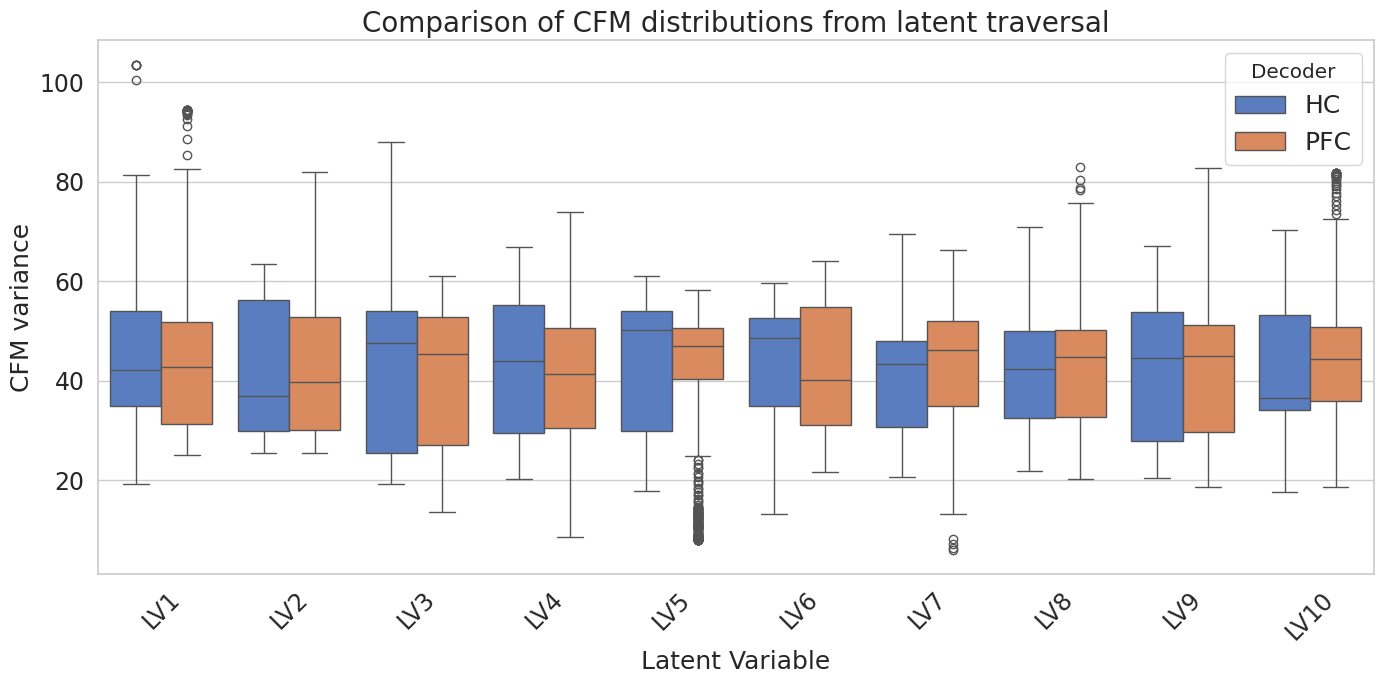

In [27]:
# plot cfm variance across traversal
plot_variance_comparison(all_cfm_hc, all_cfm_pfc, 'CFM', latent_space_comb.columns[:latent_dim])

In [28]:
torch.var(torch.tensor(all_cfm_pfc[0]))

tensor(181.9857)

In [29]:
torch.var(torch.tensor(all_cfm_hc[0]))

tensor(181.9715)

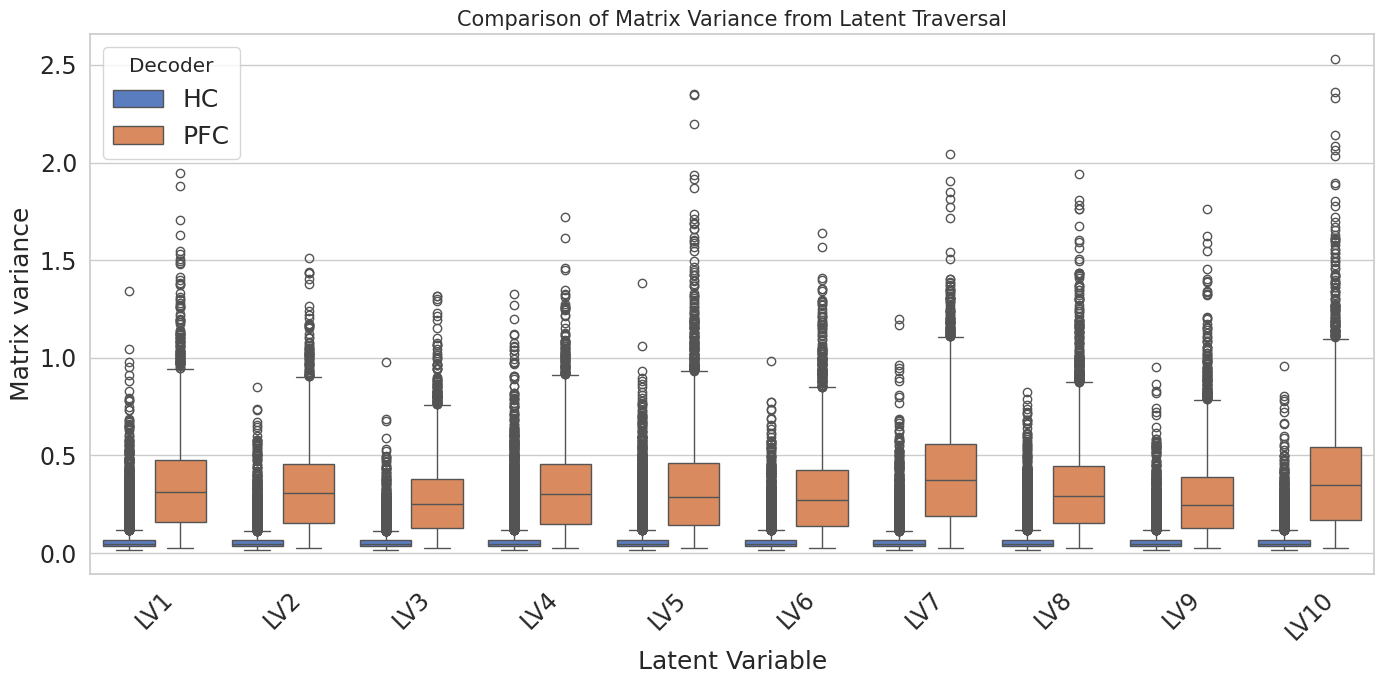

In [30]:
# plot variance across matrix variance traversal
plot_variance_comparison(hc_variance_allgenes, pfc_variance_allgenes, 'Matrix', latent_space_comb.columns[:latent_dim])

In [31]:
def plot_vector_grid(list_1, list_2, labels=None):
    num_vars = len(list_1)
    cols = 2
    rows = (num_vars + 1) // 2
    fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows), sharex=True)
    axes = axes.flatten()

    for i in range(num_vars):
        label = labels[i] if labels is not None else f"LV {i+1}"
        
        axes[i].plot(np.ravel(list_1[i]), color='#1f77b4', label='HC', alpha=0.7, linewidth=3)
        axes[i].plot(np.ravel(list_2[i]), color='#ff7f0e', label='PFC', alpha=0.7, linewidth=3)
        
        axes[i].set_title(label)
        axes[i].set_ylabel('CFM')
        axes[i].set_xlabel('Step along dimension')
        axes[i].legend()
        axes[i].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

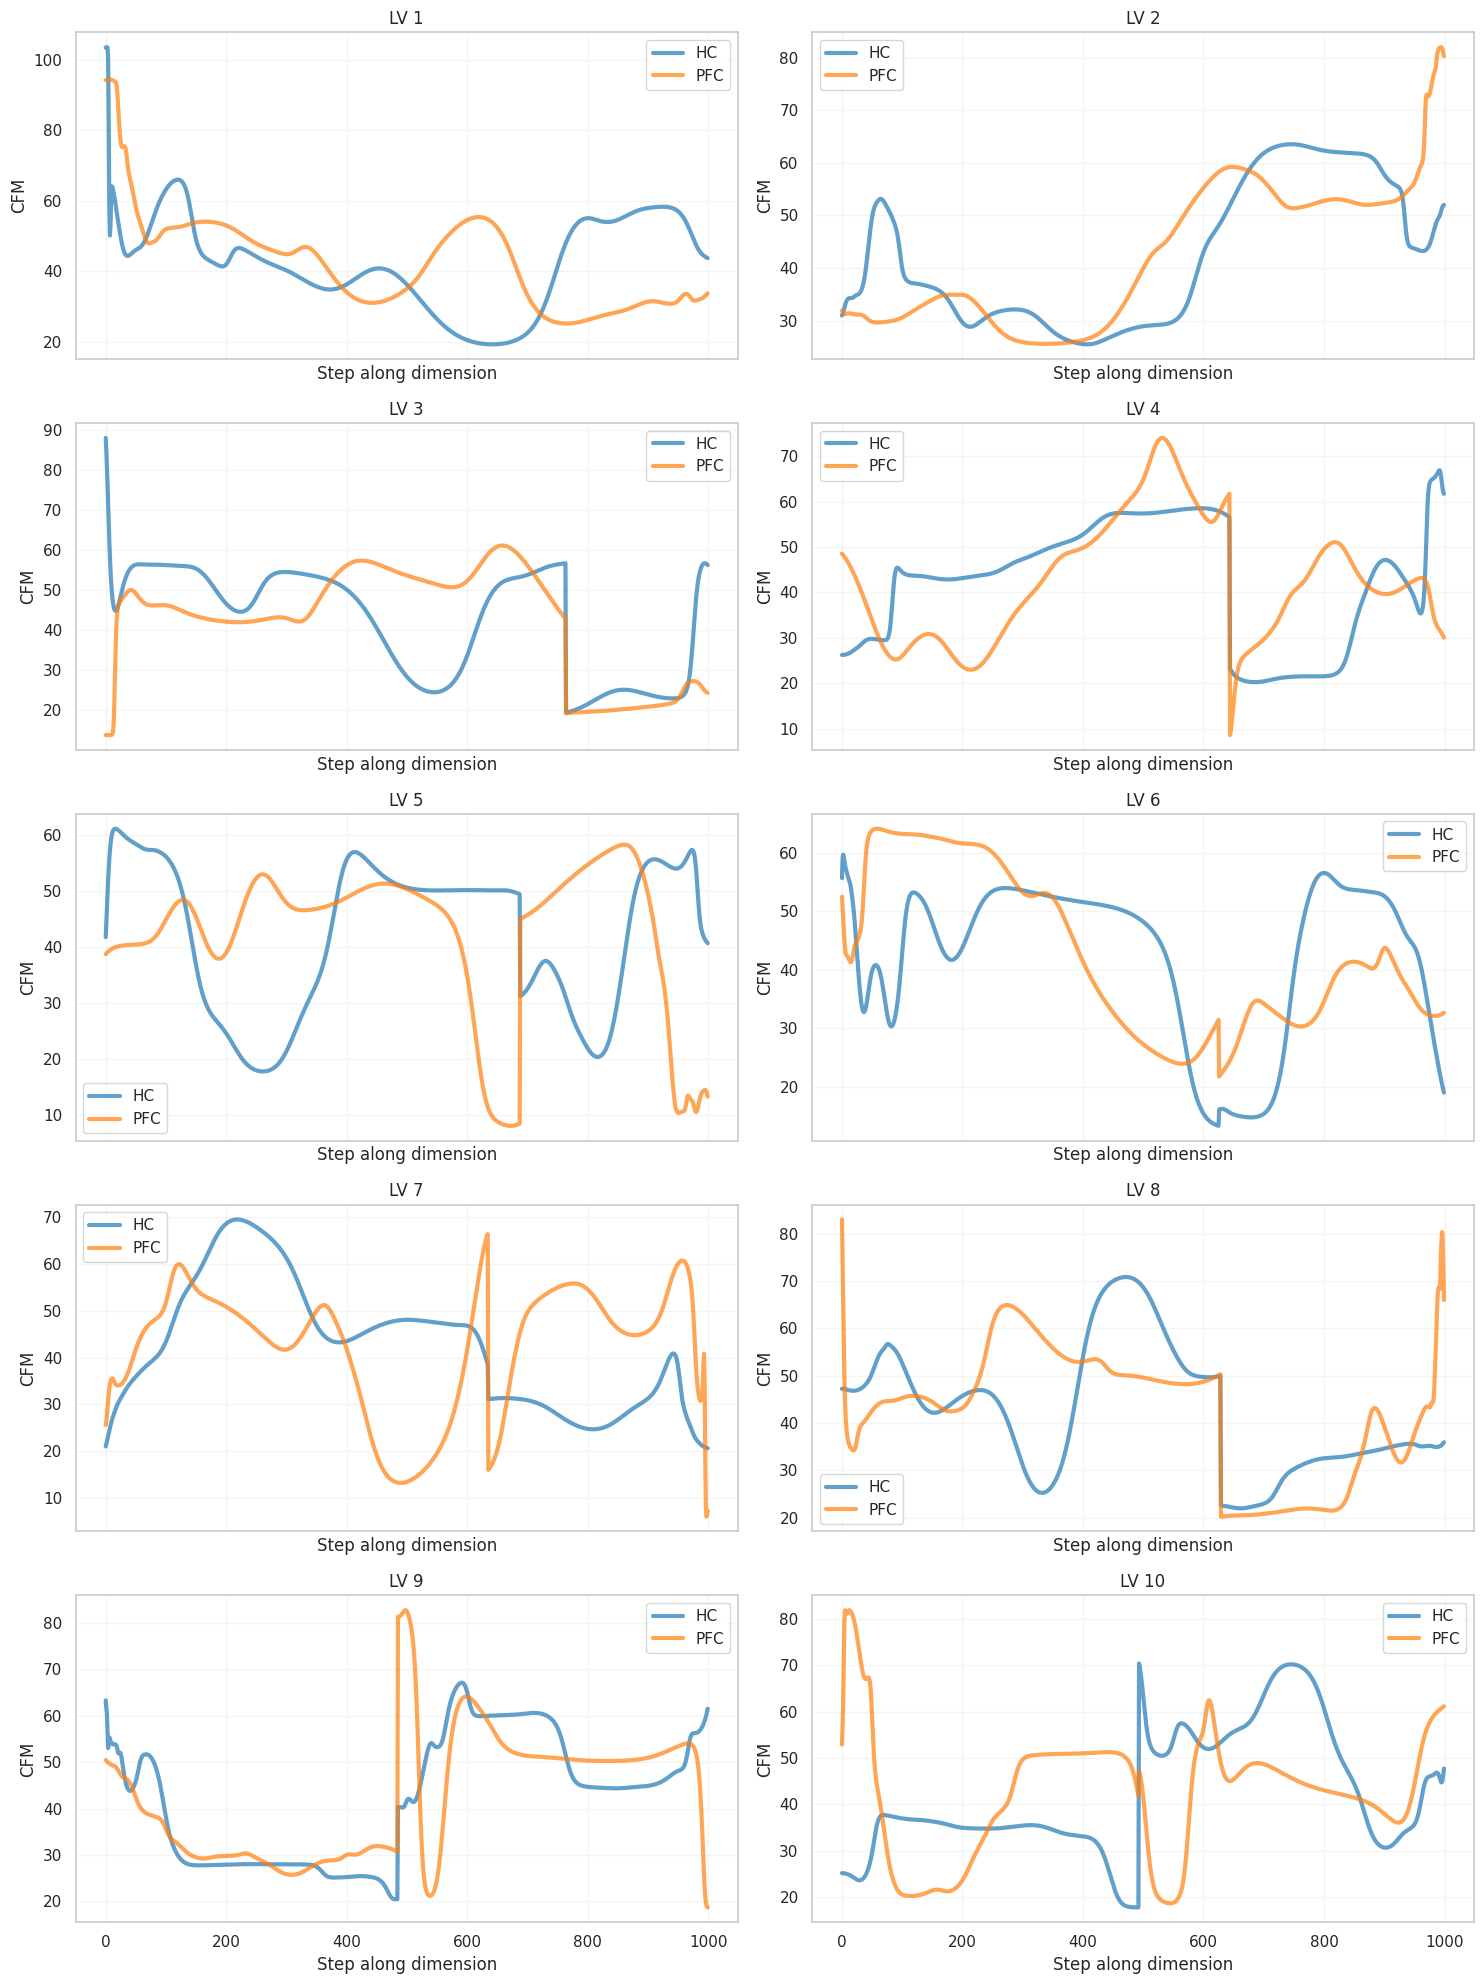

In [32]:
plot_vector_grid(all_cfm_hc, all_cfm_pfc)

Examine correlation of variance with correlation

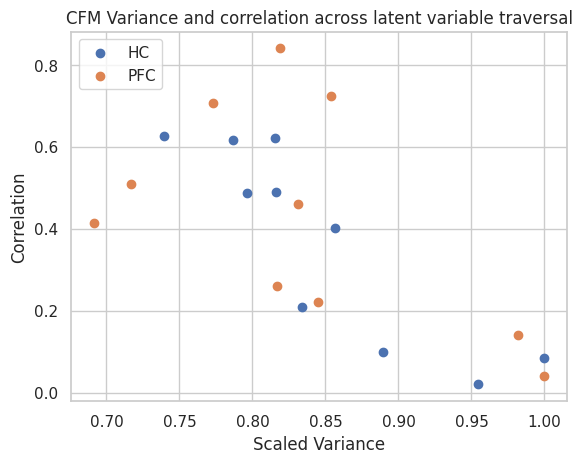

In [33]:
from scipy import stats
r_hc, p_hc = stats.pearsonr(hc_variance, np.abs(hc_corr))
plt.scatter(hc_variance / np.max(hc_variance), np.abs(hc_corr), label=f'HC')
r_pfc, p_pfc = stats.pearsonr(pfc_variance, np.abs(pfc_corr))
plt.scatter(pfc_variance / np.max(pfc_variance), np.abs(pfc_corr), label=f'PFC')
plt.xlabel('Scaled Variance')
plt.ylabel('Correlation')
plt.title('CFM Variance and correlation across latent variable traversal')
plt.legend(loc='upper left')

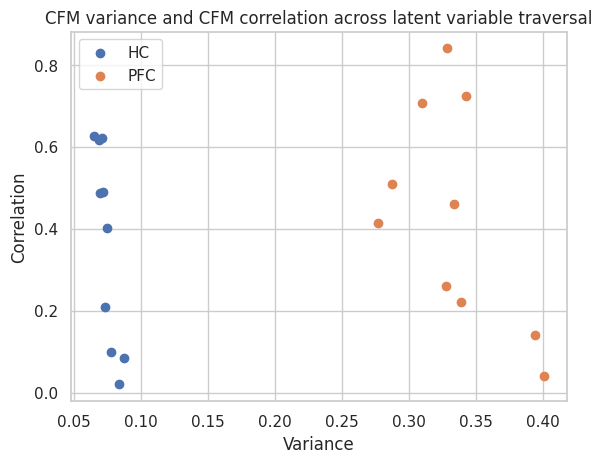

In [34]:
r_hc, p_hc = stats.pearsonr(hc_variance, np.abs(hc_corr))
plt.scatter(hc_variance, np.abs(hc_corr), label=f'HC')
r_pfc, p_pfc = stats.pearsonr(pfc_variance, np.abs(pfc_corr))
plt.scatter(pfc_variance, np.abs(pfc_corr), label=f'PFC')
plt.xlabel('Variance')
plt.ylabel('Correlation')
plt.title('CFM variance and CFM correlation across latent variable traversal')
plt.legend(loc='upper left')

Code for debugging reconstruction magnitude/evaluating batch norm

In [35]:
# looking at distribution of reconstructed vals
'''
plt.hist(np.concatenate(pfc_recons, axis=0).flatten(), bins=100)
plt.title('Distribution of reconstructed PFC values')

plt.hist(np.concatenate(hc_recons, axis=0).flatten(), bins=100)
plt.title('Distribution of reconstructed HC values')

'''

# looking at min/max reconstructed vals 
'''
for i in range(len(pfc_recons)):
    print(np.max(pfc_recons[i]), np.min(pfc_recons[i]))
    print(np.argmax(pfc_recons[i].flatten()), np.argmin(pfc_recons[i]))


np.max(np.concatenate(pfc_recons, axis=0).flatten()), np.min(np.concatenate(pfc_recons, axis=0).flatten())

for i in range(len(hc_recons)):
    print(np.max(hc_recons[i]), np.min(hc_recons[i]))
    print(np.argmax(hc_recons[i].flatten()), np.argmin(hc_recons[i]))

np.max(np.concatenate(hc_recons, axis=0).flatten()), np.min(np.concatenate(hc_recons, axis=0).flatten())
'''

'\nfor i in range(len(pfc_recons)):\n    print(np.max(pfc_recons[i]), np.min(pfc_recons[i]))\n    print(np.argmax(pfc_recons[i].flatten()), np.argmin(pfc_recons[i]))\n\n\nnp.max(np.concatenate(pfc_recons, axis=0).flatten()), np.min(np.concatenate(pfc_recons, axis=0).flatten())\n\nfor i in range(len(hc_recons)):\n    print(np.max(hc_recons[i]), np.min(hc_recons[i]))\n    print(np.argmax(hc_recons[i].flatten()), np.argmin(hc_recons[i]))\n\nnp.max(np.concatenate(hc_recons, axis=0).flatten()), np.min(np.concatenate(hc_recons, axis=0).flatten())\n'

Examine distribution of actually decoded values

In [36]:
vae.train() # to examine trained decoder

MM_CGMVAE(
  (vaes): ModuleList(
    (0): Autoencoder_CGMVAE(
      (label): Embedding(4, 1)
      (encoder1): Sequential(
        (0): Linear(in_features=4844, out_features=128, bias=True)
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): Sigmoid()
        (3): Linear(in_features=128, out_features=64, bias=True)
        (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): Sigmoid()
        (6): Linear(in_features=64, out_features=32, bias=True)
        (7): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (8): Sigmoid()
      )
      (mu): Sequential(
        (0): Linear(in_features=32, out_features=40, bias=True)
      )
      (logsigma): Sequential(
        (0): Linear(in_features=32, out_features=40, bias=True)
      )
      (decoder): Sequential(
        (0): Linear(in_features=11, out_features=32, bias=True)
        (1): Sigmoid()
        (2

/tmp/ipykernel_435862/4175782144.py:1: DtypeWarning: Columns (9712) have mixed types. Specify dtype option on import or set low_memory=False.
  norm = pd.read_csv('/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/hc_pfc_adbxd_paired_30perc.csv')


0.9424028299844975


(array([4.0000000e+00, 2.8000000e+01, 1.2600000e+02, 6.0800000e+02,
        2.6790000e+03, 4.7207343e+07, 2.7470000e+03, 6.3500000e+02,
        1.6100000e+02, 1.1000000e+01]),
 array([-66.34912872, -54.25197983, -42.15483093, -30.05768013,
        -17.96053123,  -5.86338234,   6.23376703,  18.33091545,
         30.42806625,  42.52521515,  54.62236404]),
 <BarContainer object of 10 artists>)

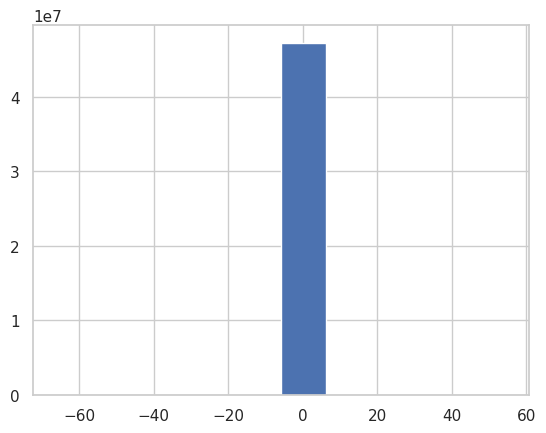

In [37]:
norm = pd.read_csv('/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/hc_pfc_adbxd_paired_30perc.csv')
actual_m1 = norm.iloc[:, :4842].values
actual_m2 = norm.iloc[:, 4842+10:-11].values

original_recon_m1, _ = vae.vaes[0].decode(
    torch.tensor(latent_space_1.iloc[:, :latent_dim].values, dtype=torch.float32).to(device), 
    torch.tensor(latent_space_1['bin'].values, dtype=torch.long).to(device)
)

recon_m1_l1_mse = np.mean(np.square(original_recon_m1[:, :-1].detach().cpu().numpy() - actual_m1))
print(recon_m1_l1_mse)
np.var((original_recon_m1.detach().cpu().numpy()[:, :-1]), axis=0).mean()
np.min((original_recon_m1.detach().cpu().numpy()[:, :-1]).flatten()), np.max((original_recon_m1.detach().cpu().numpy()[:, :-1]).flatten()), np.std((original_recon_m1.detach().cpu().numpy()[:, :-1]).flatten()), np.mean((original_recon_m1.detach().cpu().numpy()[:, :-1]).flatten())

plt.hist((original_recon_m1.detach().cpu().numpy()[:, :-1]).flatten()) # plot corresponsing histogram 

0.9784684616305918


(array([1.000000e+00, 5.000000e+00, 2.400000e+01, 5.600000e+01,
        1.840000e+02, 4.721362e+07, 3.210000e+02, 9.000000e+01,
        2.700000e+01, 1.400000e+01]),
 array([-97.28238678, -79.99749756, -62.71260071, -45.42770767,
        -28.14281464, -10.8579216 ,   6.42697144,  23.71186447,
         40.99675751,  58.28165054,  75.56654358]),
 <BarContainer object of 10 artists>)

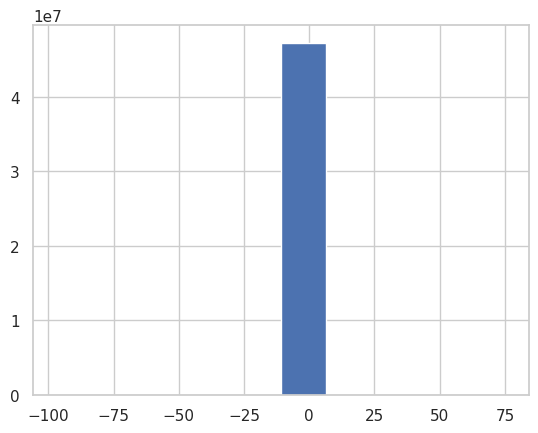

In [38]:
original_recon_m1_ls2, _ = vae.vaes[0].decode(
    torch.tensor(latent_space_2.iloc[:, :latent_dim].values, dtype=torch.float32).to(device), 
    torch.tensor(latent_space_2['bin'].values, dtype=torch.long).to(device)
)

recon_m1_ls2_mse = np.mean(np.square(original_recon_m1_ls2[:, :-1].detach().cpu().numpy() - actual_m1))
print(recon_m1_ls2_mse)

np.min((original_recon_m1_ls2.detach().cpu().numpy()[:, :-1]).flatten()), np.max((original_recon_m1_ls2.detach().cpu().numpy()[:, :-1]).flatten()), np.std((original_recon_m1_ls2.detach().cpu().numpy()[:, :-1]).flatten()), np.mean((original_recon_m1_ls2.detach().cpu().numpy()[:, :-1]).flatten())
plt.hist((original_recon_m1_ls2.detach().cpu().numpy()[:, :-1]).flatten())

1.34373462078757


(array([1.030000e+02, 4.910000e+02, 9.580000e+02, 1.970000e+03,
        4.727909e+07, 7.112000e+03, 1.518000e+03, 8.090000e+02,
        2.640000e+02, 3.500000e+01]),
 array([-119.43533325,  -94.44954681,  -69.46376038,  -44.47797394,
         -19.4921875 ,    5.49359894,   30.47938538,   55.46517181,
          80.45095825,  105.43674469,  130.42253113]),
 <BarContainer object of 10 artists>)

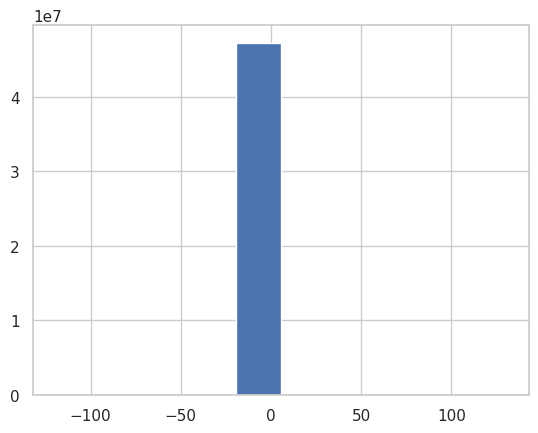

In [39]:
original_recon_m2_ls1, _ = vae.vaes[1].decode(
    torch.tensor(latent_space_1.iloc[:, :latent_dim].values, dtype=torch.float32).to(device), 
    torch.tensor(latent_space_1['bin'].values, dtype=torch.long).to(device)
)
np.min((original_recon_m2_ls1.detach().cpu().numpy()[:, :-1]).flatten()), np.max((original_recon_m2_ls1.detach().cpu().numpy()[:, :-1]).flatten()), np.std((original_recon_m2_ls1.detach().cpu().numpy()[:, :-1]).flatten()), np.mean((original_recon_m2_ls1.detach().cpu().numpy()[:, :-1]).flatten())
recon_m2_ls1_mse = np.mean(np.square(original_recon_m2_ls1[:, :-1].detach().cpu().numpy() - actual_m2))
print(recon_m2_ls1_mse)
plt.hist((original_recon_m2_ls1.detach().cpu().numpy()[:, :-1]).flatten())

(array([3.2000000e+01, 3.6300000e+02, 1.7110000e+03, 5.3080000e+03,
        4.7266472e+07, 1.4437000e+04, 3.0390000e+03, 8.7900000e+02,
        1.0000000e+02, 9.0000000e+00]),
 array([-112.34252167,  -88.60860443,  -64.87469482,  -41.14077759,
         -17.40686417,    6.32704926,   30.06096268,   53.7948761 ,
          77.52879333,  101.26270294,  124.99662018]),
 <BarContainer object of 10 artists>)

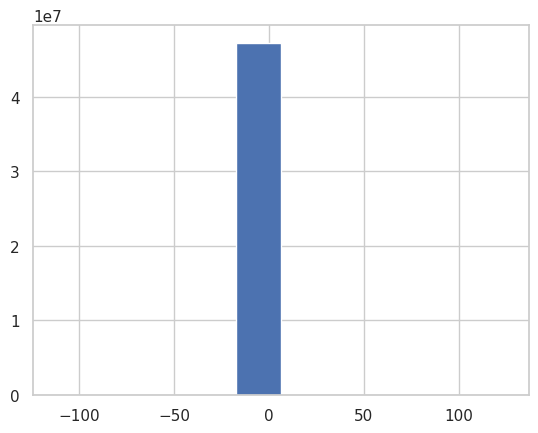

In [40]:
original_recon_m2_ls2, _ = vae.vaes[1].decode(
    torch.tensor(latent_space_2.iloc[:, :latent_dim].values, dtype=torch.float32).to(device), 
    torch.tensor(latent_space_2['bin'].values, dtype=torch.long).to(device)
)
np.min((original_recon_m2_ls2.detach().cpu().numpy()[:, :-1]).flatten()), np.max((original_recon_m2_ls2.detach().cpu().numpy()[:, :-1]).flatten()), np.std((original_recon_m2_ls2.detach().cpu().numpy()[:, :-1]).flatten()), np.mean((original_recon_m2_ls2.detach().cpu().numpy()[:, :-1]).flatten())
plt.hist((original_recon_m2_ls2.detach().cpu().numpy()[:, :-1]).flatten())

Looking at reconstruction distributions across training

(array([4.4000000e+01, 4.4000000e+01, 1.8000000e+02, 3.0200000e+02,
        4.7222716e+07, 4.6200000e+02, 1.7600000e+02, 1.1200000e+02,
        3.1000000e+01, 2.6000000e+01]),
 array([-114.61596 ,  -89.552002,  -64.488044,  -39.424086,  -14.360128,
          10.70383 ,   35.767788,   60.831746,   85.895704,  110.959662,
         136.02362 ]),
 <BarContainer object of 10 artists>)

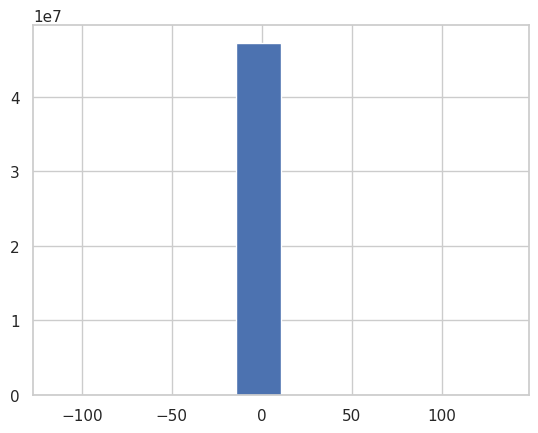

In [41]:
recon_2500 = pd.read_csv('/home/rachel/Desktop/mm-vae results/multiregion_adbxd_cr_figureResults/multiregion_samecenters_seed10_trainosd50_V2/reconHC_epoch2500_vaeHC.csv')
np.min(recon_2500.iloc[:, :-2].values), np.max(recon_2500.iloc[:, :-2].values), np.std(recon_2500.iloc[:, :-2].values), np.mean(recon_2500.iloc[:, :-2].values)
plt.hist(recon_2500.iloc[:, :-2].values.flatten())

In [42]:
recon_2500_pfc = pd.read_csv('/home/rachel/Desktop/mm-vae results/multiregion_adbxd_cr_figureResults/multiregion_samecenters_seed10_trainosd50_V2/reconPFC_epoch2500_vaePFC.csv')
np.min(recon_2500_pfc.iloc[:, :-2].values), np.max(recon_2500_pfc.iloc[:, :-2].values), np.std(recon_2500_pfc.iloc[:, :-2].values), np.mean(recon_2500_pfc.iloc[:, :-2].values)

(-305.27594, 296.0895, 1.9868687118573203, 0.0014366115960457104)

In [43]:
recon_5000 = pd.read_csv('/home/rachel/Desktop/mm-vae results/multiregion_adbxd_cr_figureResults/multiregion_samecenters_seed10_trainosd50_V2/reconHC_epoch5000_vaeHC.csv')
np.min(recon_5000.iloc[:, :-2].values), np.max(recon_5000.iloc[:, :-2].values), np.std(recon_5000.iloc[:, :-2].values), np.mean(recon_5000.iloc[:, :-2].values)

(-217.12167, 190.21378, 0.4792064306988796, 0.00025728059323477584)

Calculate percentage of total reconstruction variance explained by each LV

In [44]:
# load in mean and std for generating decoded cfm
stats_cfm = pd.read_csv('/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/stats_cfm.csv')
cfm_mean, cfm_std = stats_cfm['mean'].item(), stats_cfm['std'].item()

In [45]:
# original_recon_m1: HCrecon_fromHC
# original_recon_m1_ls2: HCrecon_fromPFC
# original_recon_m2_ls1: PFCrecon_fromHC
# original_recon_m2_ls2: PFCrecon_fromPFC
all_HC_recon = torch.cat([original_recon_m1, original_recon_m1_ls2], dim=0)
all_PFC_recon = torch.cat([original_recon_m2_ls1, original_recon_m2_ls2], dim=0)
total_HC_reconstruction_variance = torch.var(all_HC_recon[:, :-1], dim=0).mean().item()
total_PFC_reconstruction_variance = torch.var(all_PFC_recon[:, :-1], dim=0).mean().item()
total_HC_CFM_reconstruction_variance = torch.var(all_HC_recon[:, -1] * cfm_std + cfm_mean)
total_PFC_CFM_reconstruction_variance = torch.var(all_PFC_recon[:, -1] * cfm_std + cfm_mean)

In [51]:
total_HC_reconstruction_variance, total_PFC_reconstruction_variance

(0.0727921649813652, 0.5204950571060181)

Text(0, 0.5, 'Percent total variance')

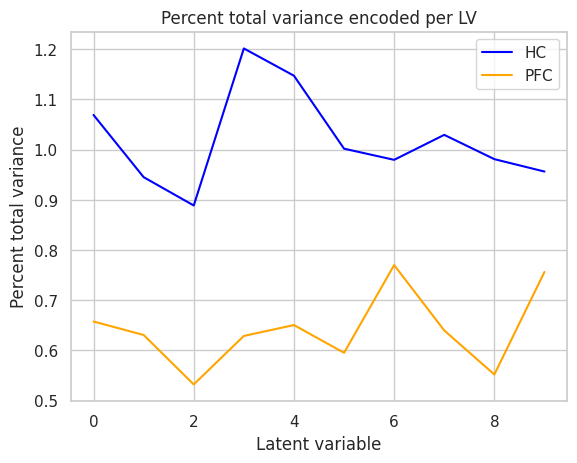

In [46]:
plt.plot(torch.tensor(hc_variance) / total_HC_reconstruction_variance, color = 'blue', label='HC')
plt.plot(torch.tensor(pfc_variance) / total_PFC_reconstruction_variance, color = 'orange', label='PFC')
plt.legend()
plt.title('Percent total variance encoded per LV')
plt.xlabel('Latent variable')
plt.ylabel('Percent total variance')

/tmp/ipykernel_435862/784836473.py:1: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  all_cfm_hc_tensor = torch.tensor(all_cfm_hc, dtype=torch.float32)


Text(0, 0.5, 'Percent total CFM variance')

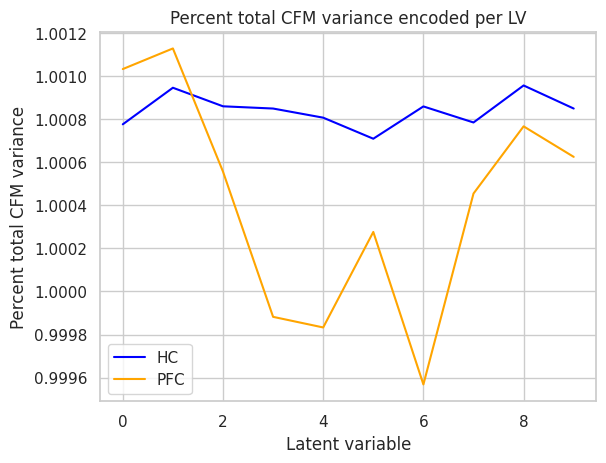

In [47]:
all_cfm_hc_tensor = torch.tensor(all_cfm_hc, dtype=torch.float32)
all_cfm_pfc_tensor = torch.tensor(all_cfm_pfc, dtype=torch.float32)
all_cfm_hc_variance = torch.var(all_cfm_hc_tensor, dim=1)
all_cfm_pfc_variance = torch.var(all_cfm_pfc_tensor, dim=1)
plt.plot((all_cfm_hc_variance / total_HC_CFM_reconstruction_variance).detach(), color = 'blue', label='HC')
plt.plot((all_cfm_pfc_variance / total_PFC_CFM_reconstruction_variance).detach(), color = 'orange', label='PFC')
plt.legend()
plt.title('Percent total CFM variance encoded per LV')
plt.xlabel('Latent variable')
plt.ylabel('Percent total CFM variance')

Compare batch normalization stats 

In [48]:
def inspect_decoder_bn(decoder, latent_z):
    """
    decoder: your model's decoder module
    latent_z: a batch of latent vectors
    """
    decoder.eval() # Usually best to inspect in eval mode to keep running stats frozen
    current_input = latent_z
    
    header = f"{'Layer Name':<25} | {'Type':<6} | {'Stored':<10} | {'Test Batch':<10} | {'Delta':<10}"
    print(header)
    print("-" * len(header))

    with torch.no_grad():
        for name, layer in decoder.named_children():
            if isinstance(layer, torch.nn.modules.batchnorm._BatchNorm):
                # Calculate Means
                s_mean = layer.running_mean.mean().item()
                b_mean = current_input.mean(dim=[0, 2, 3] if current_input.dim() == 4 else 0).mean().item()
                
                # Calculate Stds
                s_std = torch.sqrt(layer.running_var).mean().item()
                b_std = current_input.std(dim=[0, 2, 3] if current_input.dim() == 4 else 0).mean().item()
                
                # Print Mean Row
                print(f"{name:<25} | Mean   | {s_mean:>10.4f} | {b_mean:>10.4f} | {abs(s_mean - b_mean):>10.4f}")
                # Print Std Row
                print(f"{'':<25} | Std    | {s_std:>10.4f} | {b_std:>10.4f} | {abs(s_std - b_std):>10.4f}")
                print("-" * len(header))
            
            # Move to next layer
            current_input = layer(current_input)


In [49]:
inspect_decoder_bn(vae.vaes[0].decoder, torch.tensor(latent_space_2.iloc[:, :latent_dim+1].values, dtype=torch.float32).to(device))

Layer Name                | Type   | Stored     | Test Batch | Delta     
-------------------------------------------------------------------------
2                         | Mean   |     0.4739 |     0.4737 |     0.0001
                          | Std    |     0.2615 |     0.2373 |     0.0243
-------------------------------------------------------------------------
5                         | Mean   |     0.5450 |     0.5566 |     0.0115
                          | Std    |     0.1391 |     0.0904 |     0.0487
-------------------------------------------------------------------------
8                         | Mean   |     0.4580 |     0.4614 |     0.0035
                          | Std    |     0.2776 |     0.1904 |     0.0873
-------------------------------------------------------------------------
11                        | Mean   |     0.4991 |     0.4980 |     0.0011
                          | Std    |     0.1079 |     0.1521 |     0.0441
--------------------------------------

Find latent correlation with cfm

In [50]:
latents_cfm = latent_space_comb.iloc[:, :latent_dim]
latents_cfm['cfm'] = latent_space_comb['cfm']
correlations = latents_cfm.corr()['cfm'].drop('cfm').sort_values(ascending=False)
print('correlations with cfm')
print(correlations)
latents_qrt = latent_space_comb.iloc[:, :latent_dim]
latents_qrt['14-6-residual'] = latent_space_comb['14-6-residual']
corr_qrt = latents_qrt.corr()['14-6-residual'].drop('14-6-residual').sort_values(ascending=False)
print('correlations with QRT')
print(corr_qrt)
correlation, p = pearsonr(temp['PP'], latents_cfm['cfm'])
print(f'PP correlation with CFM: {correlation}')
corrrelation, p = pearsonr(temp['PP'], latents_qrt['14-6-residual'])
print(f'PP correlation with QRT: {correlation}')

correlations with cfm
LV9     0.642391
LV10    0.637884
LV1     0.633658
LV3     0.628444
LV8     0.621789
LV2     0.616735
LV6     0.614684
LV7     0.614442
LV5     0.605013
LV4     0.592350
Name: cfm, dtype: float64
correlations with QRT
LV1     0.920178
LV10    0.917432
LV9     0.917309
LV7     0.916258
LV8     0.914894
LV6     0.914173
LV2     0.913297
LV4     0.912768
LV3     0.911618
LV5     0.909775
Name: 14-6-residual, dtype: float64
PP correlation with CFM: 0.6259496208018831
PP correlation with QRT: 0.6259496208018831
